In [1]:
import os
import json
import faiss
import torch
import numpy as np
import polars as pl

from torch import nn

from math import ceil
from pathlib import Path
from collections import defaultdict
from datasets import load_from_disk
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from typing import Dict, Iterable, List, Optional, Any, Union, Literal, Tuple, Callable


from lightning.pytorch.loggers import WandbLogger

class Tokenizer:
    def __init__(
        self,
        codes_parquet_fp: str,
        special_tokens: Optional[Iterable[str]] = None,
        force_special_ids: bool = True,  # pin [PAD]=0 etc.
    ):
        if special_tokens is None:
            special_tokens = ["[PAD]", "[MASK]", "[CLS]", "[UNK]"]


        df_codes = pl.read_parquet(str(codes_parquet_fp), columns=["code"])
        base_codes = df_codes.get_column("code").to_list()
        seen = set()
        unique_codes = []
        for c in base_codes:
            if c not in seen:
                unique_codes.append(c)
                seen.add(c)

        vocab_list: List[str] = []
        special_tokens = list(special_tokens)

        if force_special_ids:
            for tok in ["[PAD]", "[MASK]", "[CLS]", "[UNK]"]:
                if tok in special_tokens and tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)
                elif tok in special_tokens and tok in seen:

                    vocab_list.append(tok)
            for tok in special_tokens:
                if tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)
        else:
            for tok in special_tokens:
                if tok not in seen:
                    vocab_list.append(tok)
                    seen.add(tok)


        vocab_list.extend(unique_codes)


        self.id2code: List[str] = vocab_list
        self.code2id: Dict[str, int] = {tok: idx for idx, tok in enumerate(vocab_list)}
        self.vocab_size: int = len(self.id2code)

        self.pad_token  = "[PAD]" if "[PAD]" in self.code2id else None
        self.mask_token = "[MASK]" if "[MASK]" in self.code2id else None
        self.cls_token  = "[CLS]" if "[CLS]" in self.code2id else None
        self.unk_token  = "[UNK]" if "[UNK]" in self.code2id else None

        self.pad_id  = self.code2id[self.pad_token]  if self.pad_token  else 0
        self.mask_id = self.code2id[self.mask_token] if self.mask_token else None
        self.cls_id  = self.code2id[self.cls_token]  if self.cls_token  else None
        self.unk_id  = self.code2id[self.unk_token]  if self.unk_token  else None


        type_set = set()
        for tok in self.id2code:
            prefix = tok.split("//", 1)[0]
            type_set.add(prefix)

        types_sorted = sorted(t for t in type_set if t not in ("[PAD]",))
        self.type2id: Dict[str, int] = {"[PAD]": 0}
        next_id = 1
        for sp in ["[MASK]", "[CLS]", "[UNK]"]:
            if sp in type_set:
                self.type2id[sp] = next_id; next_id += 1
        for t in types_sorted:
            if t not in self.type2id:
                self.type2id[t] = next_id
                next_id += 1

        self._code2id_df = pl.DataFrame({"code": self.id2code,
                                         "input_id": list(range(self.vocab_size))}) \
                               .with_columns(pl.col("code").cast(pl.Categorical))
        self._type2id_df = pl.DataFrame({"code_type": list(self.type2id.keys()),
                                         "type_id":   list(self.type2id.values())}) \
                               .with_columns(pl.col("code_type").cast(pl.Categorical))


    def encode(self, codes: Iterable[str]) -> List[int]:
        get = self.code2id.get
        if self.unk_id is not None:
            fallback = self.unk_id
        else:
            fallback = self.pad_id if self.pad_id is not None else 0
        return [get(c, fallback) for c in codes]

    def decode(self, ids: Iterable[int]) -> List[str]:
        out = []
        for i in ids:
            if 0 <= i < self.vocab_size:
                out.append(self.id2code[i])
            else:
                out.append(self.unk_token or "[UNK]")
        return out

    def save(self, path: str) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        obj = {
            "id2code": self.id2code,
            "special_tokens": [t for t in ["[PAD]", "[MASK]", "[CLS]", "[UNK]"] if t in self.code2id],
            "type2id": self.type2id,
            "pad_id": self.pad_id,
            "mask_id": self.mask_id,
            "cls_id": self.cls_id,
            "unk_id": self.unk_id,
        }
        with open(path, "w") as f:
            json.dump(obj, f, indent=2)

    @classmethod
    def load(cls, path: str) -> "Tokenizer":
        path = Path(path)
        with open(path) as f:
            obj = json.load(f)

        tok = cls.__new__(cls) 

        tok.id2code = obj["id2code"]
        tok.code2id = {tok_: i for i, tok_ in enumerate(tok.id2code)}
        tok.vocab_size = len(tok.id2code)

        tok.special_tokens = obj.get("special_tokens", [])
        tok.type2id = obj.get("type2id", {})

        tok.pad_token  = "[PAD]" if "[PAD]" in tok.code2id else None
        tok.mask_token = "[MASK]" if "[MASK]" in tok.code2id else None
        tok.cls_token  = "[CLS]" if "[CLS]" in tok.code2id else None
        tok.unk_token  = "[UNK]" if "[UNK]" in tok.code2id else None

        tok.pad_id  = obj.get("pad_id", tok.code2id.get("[PAD]", 0))
        tok.mask_id = obj.get("mask_id", tok.code2id.get("[MASK]")) if "[MASK]" in tok.code2id else None
        tok.cls_id  = obj.get("cls_id", tok.code2id.get("[CLS]"))   if "[CLS]" in tok.code2id else None
        tok.unk_id  = obj.get("unk_id", tok.code2id.get("[UNK]"))   if "[UNK]" in tok.code2id else None

        # Rebuild Polars lookup frames
        tok._code2id_df = pl.DataFrame({"code": tok.id2code,
                                        "input_id": list(range(tok.vocab_size))}) \
                              .with_columns(pl.col("code").cast(pl.Categorical))
        tok._type2id_df = pl.DataFrame({"code_type": list(tok.type2id.keys()),
                                        "type_id":   list(tok.type2id.values())}) \
                              .with_columns(pl.col("code_type").cast(pl.Categorical))
        return tok

    @property
    def code2id_df(self) -> pl.DataFrame:
        return self._code2id_df

    @property
    def type2id_df(self) -> pl.DataFrame:
        return self._type2id_df
    

In [2]:
class SequencesGenerator:
    def __init__(
        self,
        tokenizer_path: str,
        chunk_length: int = 1024,
        overlap: int = 128,
        return_numeric: bool = False,
        return_text: bool = False,
        return_time: bool = False,
        return_ids: bool = False,
    ):

        self.tokenizer = Tokenizer.load(tokenizer_path)
        self.chunk_length = chunk_length
        self.overlap = overlap
        self.return_numeric = return_numeric
        self.return_text = return_text
        self.return_time = return_time
        self.return_ids = return_ids

    def encode_sequence(
        self,
        timeline: pl.DataFrame,
        max_length: Optional[int] = None,
        pad_to_max: bool = False,
        truncation: Literal["head", "tail"] = "tail",
        add_cls: bool = False,
    ) -> Dict[str, Union[List[int], List[float], List[str]]]:
        """
        Vectorized build of:
          input_ids, attention_mask, visit_ids, stage_ids, type_ids
          + optional numeric/text streams (+ masks)
        """
        df = timeline
        
        if "seq_id" in df.columns:

            uniq = df.select(pl.col("seq_id")).unique(maintain_order=True)
            uniq = uniq.with_row_count(name="visit_ids_raw")  # 0..K-1
            df = df.join(uniq, on="seq_id", how="left").with_columns(
                (pl.col("visit_ids_raw") ).alias("visit_id").fill_null(0)
            ).drop("visit_ids_raw")
        else:
            df = df.with_columns(pl.lit(0).alias("visit_id"))

        stage_cols = ["out_id", "er_id", "hadm_id", "icustay_id"]
        present_stages = [c for c in stage_cols if c in df.columns]
        if present_stages:

            expr = pl.lit(0)
            for i, col in enumerate(present_stages, start=1):
                expr = pl.when(expr.eq(0) & pl.col(col).is_not_null()).then(i).otherwise(expr)
            df = df.with_columns(expr.alias("stage_id"))
        else:
            df = df.with_columns(pl.lit(0).alias("stage_id"))

        df = df.join(
            self.tokenizer.type2id_df,
            on=pl.col("code_type").cast(pl.Categorical),
            how="left",
        ).with_columns(pl.col("type_id").fill_null(0))

        df = df.join(
            self.tokenizer.code2id_df,
            on=pl.col("code").cast(pl.Categorical),
            how="left",
        )


        unk_id = self.tokenizer.unk_id if self.tokenizer.unk_id is not None else self.tokenizer.pad_id or 0
        df = df.with_columns(pl.col("input_id").fill_null(unk_id))

        df = df.with_columns(
            pl.when(pl.col("code").str.starts_with("TIME-GAP//"))
              .then(0)
              .otherwise(pl.col("visit_id"))
              .alias("visit_id"),
            pl.when(pl.col("code").str.starts_with("TIME-GAP//"))
              .then(0)
              .otherwise(pl.col("stage_id"))
              .alias("stage_id"),
        )


        if add_cls and (self.tokenizer.cls_token is not None):
            cls_row = {
                "code": self.tokenizer.cls_token,
                "code_type": "[CLS]",
                "visit_id": 0,
                "stage_id": 0,
                "type_id": self.tokenizer.type2id.get("[CLS]", 0),
                "input_id": self.tokenizer.cls_id,
            }

            if self.return_numeric:
                cls_row["numeric_value"] = None
            if self.return_text:
                cls_row["text_value"] = None

            df = pl.concat([pl.DataFrame([cls_row]), df], how="vertical_relaxed")


        input_ids = df.get_column("input_id").cast(pl.Int64).to_list()
        type_ids = df.get_column("type_id").cast(pl.Int64).to_list()
        visit_ids = df.get_column("visit_id").cast(pl.Int64).to_list()
        stage_ids = df.get_column("stage_id").cast(pl.Int64).to_list()
        attention_mask = [1] * len(input_ids)


        value_payload = self._build_value_streams(
            df=df,
            max_length=max_length,
            pad_to_max=pad_to_max,
            truncation=truncation,
        )

        # --- truncate/pad core streams in one go ---
        input_ids      = self._truncate(input_ids,      max_length, truncation)
        type_ids       = self._truncate(type_ids,       max_length, truncation)
        visit_ids      = self._truncate(visit_ids,      max_length, truncation)
        stage_ids      = self._truncate(stage_ids,      max_length, truncation)
        attention_mask = [1] * len(input_ids)

        if pad_to_max and max_length is not None and len(input_ids) < max_length:
            pad_len = max_length - len(input_ids)
            pad_id = self.tokenizer.pad_id if self.tokenizer.pad_id is not None else 0
            input_ids      = input_ids + [pad_id] * pad_len
            type_ids       = type_ids + [0] * pad_len
            visit_ids      = visit_ids + [0] * pad_len
            stage_ids      = stage_ids + [0] * pad_len
            attention_mask = attention_mask + [0] * pad_len

        out = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "visit_ids": visit_ids,
            "stage_ids": stage_ids,
            "type_ids": type_ids,
        }
        out.update(value_payload)
        return out

    def get_overlapped_chunks(
        self,
        timeline: Dict[str, Iterable],
        chunk_length: Optional[int] = None,
        overlap: Optional[int] = None,
        add_cls_per_chunk: bool = True,
    ) -> List[Dict[str, List[Any]]]:
        """
        Sliding-window chunking with optional [CLS] per chunk and padding.
        """
        if chunk_length is None or overlap is None:
            chunk_length = self.chunk_length
            overlap = self.overlap

        fields = ["input_ids", "attention_mask", "visit_ids", "stage_ids", "type_ids"]
        for extra in ("numeric_values", "numeric_mask", "text_values", "text_mask", 'time_diff'):
            if extra in timeline and extra not in fields:
                fields.append(extra)

        n = len(timeline["input_ids"])
        payload = chunk_length - (1 if add_cls_per_chunk else 0)
        step = max(1, payload - overlap)

        num_chunks = 1 if n <= payload else ceil((n - payload) / step) + 1
        starts = [i * step for i in range(num_chunks)]

        cls_defaults = {
            "input_ids": self.tokenizer.cls_id if self.tokenizer.cls_id is not None else (self.tokenizer.pad_id or 0),
            "attention_mask": 1,
            "visit_ids": 0,
            "stage_ids": 0,
            "type_ids": self.tokenizer.type2id.get("[CLS]", 0),
            "numeric_values": 0.0,
            "numeric_mask": 0,
            "text_values": "",
            "text_mask": 0,
            "time_diff":0.0}

        chunks = []
        for start in starts:
            end = min(n, start + payload)
            sliced = {k: list(timeline[k][start:end]) for k in fields if k in timeline}

            if "attention_mask" in sliced:
                sliced["attention_mask"] = [1] * len(sliced["input_ids"])

            if add_cls_per_chunk:
                for k in list(sliced.keys()):
                    sliced[k] = [cls_defaults[k]] + sliced[k]

            cur_len = len(sliced["input_ids"])
            if cur_len < chunk_length:
                pad_len = chunk_length - cur_len
                for k in list(sliced.keys()):
                    sliced[k] = self._pad_list(sliced[k], pad_len, 0)

            chunks.append(sliced)
        return chunks


    def _build_value_streams(
        self,
        df: pl.DataFrame,
        max_length: Optional[int],
        pad_to_max: bool,
        truncation: Literal["head", "tail"],
    ) -> Dict[str, List[Any]]:
        out: Dict[str, List[Any]] = {}
        # Numeric stream
        if self.return_numeric:
            if "numeric_value" in df.columns:
                vals = df.get_column("numeric_value").to_list()
            else:
                vals = [None] * df.height
            num_mask = [1 if (v is not None) else 0 for v in vals]
            vals = [0.0 if v is None else float(v) for v in vals]

            vals = self._truncate(vals, max_length, truncation)
            num_mask = self._truncate(num_mask, max_length, truncation)

            if pad_to_max and max_length is not None and len(vals) < max_length:
                pad_len = max_length - len(vals)
                vals += [0.0] * pad_len
                num_mask += [0] * pad_len

            out["numeric_values"] = vals
            out["numeric_mask"] = num_mask

        # Text stream
        if self.return_text:
            if "text_value" in df.columns:
                txt = df.get_column("text_value").to_list()
            else:
                txt = [None] * df.height
            txt = [("" if (t is None or str(t) == "___") else str(t)) for t in txt]
            txt_mask = [1 if (t != "") else 0 for t in txt]

            txt = self._truncate(txt, max_length, truncation)
            txt_mask = self._truncate(txt_mask, max_length, truncation)

            if pad_to_max and max_length is not None and len(txt) < max_length:
                pad_len = max_length - len(txt)
                txt += [""] * pad_len
                txt_mask += [0] * pad_len

            out["text_values"] = txt
            out["text_mask"] = txt_mask

            
        if self.return_time:
            if "time_diff" in df.columns:
                df = df.with_columns(pl.col(['time_diff'])).fill_null(0.0)
                time_diff = df.get_column("time_diff").to_list()
                time_diff = self._scale_time_deltas(time_diff)
                time_stamp = df.get_column("time").to_list()
            else:
                time_diff = [None] * df.height
                time_stamp = [None] * df.height


            if pad_to_max and max_length is not None and len(time_diff) < max_length:
                pad_len = max_length - len(time_diff)
                time_diff += [0] * pad_len
                time_stamp += [0] * pad_len


            out["time_diff"] = time_diff
            out["time_stamp"] = time_stamp
            
        if self.return_ids:
            if "seq_id" in df.columns:
                
                seq_id = df.get_column("seq_id").cast(pl.Int32).to_list()
                out_id = df.get_column("out_id").cast(pl.Int32).to_list()
                er_id =  df.get_column("er_id").cast(pl.Int32).to_list()
                hadm_id = df.get_column("hadm_id").cast(pl.Int32).to_list()
                icustay_id = df.get_column("hadm_id").cast(pl.Int32).to_list()
            else:
                seq_id = [None] * df.height
                out_id = [None] * df.height
                er_id =  [None] * df.height
                hadm_id = [None] * df.height
                icustay_id = [None] * df.height

            if pad_to_max and max_length is not None and len(time_diff) < max_length:
                pad_len = max_length - len(time_diff)
                seq_id += [0] * pad_len
                out_id += [0] * pad_len
                er_id += [0] * pad_len
                hadm_id += [0] * pad_len
                icustay_id += [0] * pad_len

            out["seq_id"] = seq_id
            out["out_id"] = out_id
            out["er_id"] = er_id
            out["hadm_id"] = hadm_id
            out["icustay_id"] = icustay_id

        return out
    
    def get_time_based_chunks(
        self,
        timeline: Dict[str, Iterable],
        window_hours: float,
        anchor_from_first_valid_time: bool = True,
        keep_prefix_tokens: bool = True,
    ) -> List[Dict[str, List[Any]]]:

        if "input_ids" not in timeline:
            raise ValueError("timeline must contain 'input_ids'")
        if "time_stamp" not in timeline:
            raise ValueError("timeline must contain 'time_stamp' for time-based chunking")

        n = len(timeline["input_ids"])
        if n == 0:
            return []

        fields = [k for k, v in timeline.items() if isinstance(v, (list, tuple))]
        time_stamps = list(timeline["time_stamp"])

        def _is_valid_time(x: Any) -> bool:
            return x is not None

        anchor_idx = None
        for i, ts in enumerate(time_stamps):
            if _is_valid_time(ts):
                anchor_idx = i
                break

        if anchor_idx is None:
            return [{k: list(v) for k, v in timeline.items() if isinstance(v, (list, tuple))}]

        t0 = time_stamps[anchor_idx]
        window_size = window_hours * 3600.0

        if window_size <= 0:
            raise ValueError("window_hours must be > 0")

        prefix_idx = list(range(anchor_idx)) if keep_prefix_tokens else []

        buckets: Dict[int, List[int]] = {}
        for i in range(anchor_idx, n):
            ts = time_stamps[i]

            if not _is_valid_time(ts):
                window_id = 0
            else:
                elapsed = (ts - t0).total_seconds()
                window_id = int(elapsed // window_size) if elapsed >= 0 else 0

            buckets.setdefault(window_id, []).append(i)

        chunks: List[Dict[str, List[Any]]] = []
        for chunk_idx, window_id in enumerate(sorted(buckets.keys())):
            idxs = (prefix_idx + buckets[window_id]) if chunk_idx == 0 else buckets[window_id]

            chunk = {}
            for k in fields:
                chunk[k] = [timeline[k][j] for j in idxs]

            chunks.append(chunk)

        final_chunks = []

        for chunk in chunks:
            sub_chunks = self.get_overlapped_chunks(
                timeline=chunk,
                chunk_length=self.chunk_length,
                overlap=0,
                add_cls_per_chunk=True
            )
            final_chunks.extend(sub_chunks)

        return final_chunks
    
    def get_visit_level_chunks(
        self,
        timeline: Dict[str, Iterable],
        keep_prefix_tokens: bool = True,
    ) -> List[Dict[str, List[Any]]]:

        if "input_ids" not in timeline:
            raise ValueError("timeline must contain 'input_ids'")
        if "seq_id" not in timeline:
            raise ValueError("timeline must contain 'seq_id' for visit-level chunking")

        n = len(timeline["input_ids"])
        if n == 0:
            return []

        fields = [k for k, v in timeline.items() if isinstance(v, (list, tuple))]
        seq_ids = list(timeline["seq_id"])

        def _is_valid_visit(x: Any) -> bool:
            return x is not None and x != 0

        # find first actual visit event
        first_visit_idx = None
        for i, sid in enumerate(seq_ids):
            if _is_valid_visit(sid):
                first_visit_idx = i
                break

        # if no valid seq_id exists, return overlapped chunks on full sequence
        if first_visit_idx is None:
            return self.get_overlapped_chunks(
                timeline={k: list(v) for k, v in timeline.items() if isinstance(v, (list, tuple))},
                chunk_length=self.chunk_length,
                overlap=0,
                add_cls_per_chunk=True,
            )

        prefix_idx = list(range(first_visit_idx)) if keep_prefix_tokens else []

        buckets: Dict[Any, List[int]] = {}
        visit_order: List[Any] = []

        for i in range(first_visit_idx, n):
            sid = seq_ids[i]
            if not _is_valid_visit(sid):
                continue

            if sid not in buckets:
                buckets[sid] = []
                visit_order.append(sid)
            buckets[sid].append(i)

        raw_chunks: List[Dict[str, List[Any]]] = []
        for chunk_idx, sid in enumerate(visit_order):
            idxs = (prefix_idx + buckets[sid]) if chunk_idx == 0 else buckets[sid]

            chunk = {}
            for k in fields:
                chunk[k] = [timeline[k][j] for j in idxs]

            raw_chunks.append(chunk)

        final_chunks: List[Dict[str, List[Any]]] = []
        for chunk in raw_chunks:
            sub_chunks = self.get_overlapped_chunks(
                timeline=chunk,
                chunk_length=self.chunk_length,
                overlap=0,
                add_cls_per_chunk=True,
            )
            final_chunks.extend(sub_chunks)

        return final_chunks

    
    def get_care_stage_level_chunks(
        self,
        timeline: Dict[str, Iterable],
        keep_prefix_tokens: bool = True,
    ) -> List[Dict[str, List[Any]]]:

        if "input_ids" not in timeline:
            raise ValueError("timeline must contain 'input_ids'")
        if "seq_id" not in timeline:
            raise ValueError("timeline must contain 'seq_id' for care-stage chunking")

        n = len(timeline["input_ids"])
        if n == 0:
            return []

        fields = [k for k, v in timeline.items() if isinstance(v, (list, tuple))]

        seq_ids = list(timeline["seq_id"]) if "seq_id" in timeline else [None] * n
        er_ids = list(timeline["er_id"]) if "er_id" in timeline else [None] * n
        out_ids = list(timeline["out_id"]) if "out_id" in timeline else [None] * n
        hadm_ids = list(timeline["hadm_id"]) if "hadm_id" in timeline else [None] * n
        icu_ids = list(timeline["icustay_id"]) if "icustay_id" in timeline else [None] * n

        def _valid(x: Any) -> bool:
            return x is not None and x != 0

        # make hadm mutually exclusive with icu at the row level
        hadm_ids = [
            None if _valid(icu) else hadm
            for hadm, icu in zip(hadm_ids, icu_ids)
        ]

        # per-row stage priority
        def _stage_key(i: int):
            if _valid(icu_ids[i]):
                return ("icu", icu_ids[i])
            elif _valid(hadm_ids[i]):
                return ("hadm", hadm_ids[i])
            elif _valid(er_ids[i]):
                return ("er", er_ids[i])
            elif _valid(out_ids[i]):
                return ("out", out_ids[i])
            return None

        # first row that belongs to a visit
        first_visit_idx = None
        for i in range(n):
            if _valid(seq_ids[i]):
                first_visit_idx = i
                break

        if first_visit_idx is None:
            return self.get_overlapped_chunks(
                timeline={k: list(v) for k, v in timeline.items() if isinstance(v, (list, tuple))},
                chunk_length=self.chunk_length,
                overlap=0,
                add_cls_per_chunk=True,
            )

        prefix_idx = list(range(first_visit_idx)) if keep_prefix_tokens else []

        # group by (seq_id, stage_type, stage_id), preserving first-seen order
        buckets: Dict[Any, List[int]] = {}
        chunk_order: List[Any] = []

        for i in range(first_visit_idx, n):
            if not _valid(seq_ids[i]):
                continue

            stage = _stage_key(i)
            if stage is None:
                continue

            key = (seq_ids[i], stage[0], stage[1])

            if key not in buckets:
                buckets[key] = []
                chunk_order.append(key)
            buckets[key].append(i)

        final_chunks: List[Dict[str, List[Any]]] = []

        for chunk_idx, key in enumerate(chunk_order):
            idxs = (prefix_idx + buckets[key]) if chunk_idx == 0 else buckets[key]

            chunk = {}
            for k in fields:
                chunk[k] = [timeline[k][j] for j in idxs]

            sub_chunks = self.get_overlapped_chunks(
                timeline=chunk,
                chunk_length=self.chunk_length,
                overlap=0,
                add_cls_per_chunk=True,
            )

#             for sub_chunk in sub_chunks:
#                 sub_chunk["source_seq_id"] = key[0]
#                 sub_chunk["source_stage_type"] = key[1]
#                 sub_chunk["source_stage_id"] = key[2]

            final_chunks.extend(sub_chunks)

        return final_chunks
    
    def _scale_time_deltas(self, deltas_list):
        deltas = np.asarray(deltas_list, dtype=float)
        compressed = np.log1p(deltas)              
        scaled = compressed / np.log(5328.93125)         
        return scaled.tolist()

    @staticmethod
    def _truncate(seq: List[Any], max_length: Optional[int], truncation: str) -> List[Any]:
        if max_length is None or len(seq) <= max_length:
            return seq
        return seq[-max_length:] if truncation == "head" else seq[:max_length]

    @staticmethod
    def _pad_list(lst: List[Any], pad_len: int, pad_value: Any) -> List[Any]:
        if pad_len <= 0:
            return lst
        return lst + [pad_value] * pad_len

In [3]:
limits = {
    'within24_query': {512:  ['w24_start_512',  'w24_end_512' ],
                       1024: ['w24_start_1024', 'w24_end_1024'],
                       1536: ['w24_start_1536', 'w24_end_1536'],
                       2048: ['w24_start_2048', 'w24_end_2048'],
                      },
    
    'within24_hist_icu': {512: ['wStay_min', 'w24_start_512' ],
                         1024: ['wStay_min', 'w24_start_1024'],
                         1536: ['wStay_min', 'w24_start_1536'],
                         2048: ['wStay_min', 'w24_start_2048'],
                      },
    
    'within24_hist_full': {512: [ 0, 'w24_start_512' ],
                          1024: [ 0, 'w24_start_1024'],
                          1536: [ 0, 'w24_start_1536'],
                          2048: [ 0, 'w24_start_2048'],
                          },

    
    'within48_query': {512:  ['w48_start_512',  'w48_end_512' ],
                       1024: ['w48_start_1024', 'w48_end_1024'],
                       1536: ['w48_start_1536', 'w48_end_1536'],
                       2048: ['w48_start_2048', 'w48_end_2048'],
                      },

    'within48_hist_icu': {512: ['wStay_min', 'w48_start_512' ],
                         1024: ['wStay_min', 'w48_start_1024'],
                         1536: ['wStay_min', 'w48_start_1536'],
                         2048: ['wStay_min', 'w48_start_2048'],
                      },
    
    'within48_hist_full': {512: [ 0, 'w48_start_512' ],
                          1024: [ 0, 'w48_start_1024'],
                          1536: [ 0, 'w48_start_1536'],
                          2048: [ 0, 'w48_start_2048'],
                          },
    
    'within_stay_query': {512:  ['wStay_start_512',  'wStay_end_512' ],
                          1024: ['wStay_start_1024', 'wStay_end_1024'],
                          1536: ['wStay_start_1536', 'wStay_end_1536'],
                          2048: ['wStay_start_2048', 'wStay_end_2048'],
                         },
    
    'within_stay_hist_icu': {512:  ['wStay_min', 'wStay_start_512' ],
                             1024: ['wStay_min', 'wStay_start_1024'],
                             1536: ['wStay_min', 'wStay_start_1536'],
                             2048: ['wStay_min', 'wStay_start_2048'],
                            },
    
    'within_stay_hist_full': {512:  [ 0, 'wStay_start_512' ],
                              1024: [ 0, 'wStay_start_1024'],
                              1536: [ 0, 'wStay_start_1536'],
                              2048: [ 0, 'wStay_start_2048'],
                             },
    }

In [4]:
import random
class RetrievalDataset(Dataset):
    def __init__(self,
                 dataset_path: str,
                 data_idx_path: str,
                 vectordb_path:str,
                 tokenizer_path:str,
                 limits_dict: dict,
                 chunking_strategy:str = 'overlap',
                 task: str = 'y_mort',
                 query_window: str = 'within48_query',
                 history_window: str = 'within48_hist_full', 
                 top_k: int = 8,
                 seq_length_q: int = 512,
                 overlap_q: int= 0,
                 seq_length_h: int = 256,
                 overlap_h: int = 0,
                 use_time: bool = True,
                 use_numeric: bool = False,
                 add_cls=True,
                 window_hours: float = 6.0,
                 split: str = 'train') -> None:
        
        assert chunking_strategy in ['overlap','time','visit','care_stage']
        
        self.chunking_strategy = chunking_strategy
        
        if self.chunking_strategy == 'overlap':
            needed_cols = ['subject_id','input_ids','attention_mask','visit_ids','stage_ids','type_ids']
        elif self.chunking_strategy == 'time':
            needed_cols = ['subject_id','input_ids','attention_mask','visit_ids','stage_ids','type_ids','time_stamp']
        elif self.chunking_strategy == 'visit':
            needed_cols = ['subject_id','input_ids','attention_mask','visit_ids','stage_ids','type_ids','seq_id']
        elif self.chunking_strategy == 'care_stage':
            needed_cols = ['subject_id','input_ids','attention_mask','visit_ids','stage_ids','type_ids',
                           'seq_id', 'out_id', 'er_id', 'hadm_id', 'icustay_id']
        
        
        
        if use_time:
            needed_cols.append('time_diff')
        if use_numeric:
            needed_cols.append('numeric_values')
            needed_cols.append('numeric_mask')
            
            
        self.start_limit_q = limits_dict[query_window][seq_length_q][0]
        self.end_limit_q   = limits_dict[query_window][seq_length_q][1]
        
        self.start_limit_h = limits_dict[history_window][seq_length_q][0]
        self.end_limit_h   = limits_dict[history_window][seq_length_q][1]
        
        
        self.task = task
        self.add_cls = add_cls
        
        self.query_gen = SequencesGenerator(tokenizer_path=tokenizer_path,
                                            chunk_length=seq_length_q,
                                            overlap=overlap_q)
        self.history_gen = SequencesGenerator(tokenizer_path=tokenizer_path,
                                            chunk_length=seq_length_h,
                                            overlap=overlap_h)
        
        
        self.vectordb_path = vectordb_path
        self.top_k = top_k
        self.window_hours = window_hours
        
        self.data_idx =  pl.scan_parquet(data_idx_path).collect()
        self.data_idx =  self.data_idx.filter(pl.col('split') == split)
        
        sub_ids = set(self.data_idx.get_column("subject_id").to_list())
        hf_dataset = load_from_disk(dataset_path)

        
        hf_dataset = hf_dataset.filter(
            lambda sids: [sid in sub_ids for sid in sids],
            batched=True,
            input_columns="subject_id",)

        self.hf_dataset = (
            hf_dataset
            .flatten_indices()
            .select_columns(needed_cols)
            .with_format("numpy", columns=needed_cols, output_all_columns=False))
        
        
        sids = self.hf_dataset["subject_id"]        
        self.index = defaultdict(list)
        for i, sid in enumerate(sids):
            self.index[sid].append(i)
        

        
    def __len__(self) -> int:
        return len(self.data_idx)
    
    def _to_list(self, v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, list):
            return v
        return v
    def __getitem__(self,
                    idx: int):
        
        stay = self.data_idx[idx]
        subject_id = stay['subject_id'][0]
        stay_id = stay['icustay_id'][0]
        label = stay[self.task][0]
        
        timeline_encoded = self.hf_dataset.select(self.index[subject_id])[0]
        timeline_encoded = {k: self._to_list(v) for k, v in timeline_encoded.items()}
        
        start_q = stay[self.start_limit_q][0]
        end_q = stay[self.end_limit_q][0]
        start_h = stay[self.start_limit_h][0] if isinstance(self.start_limit_h, str) else int(self.start_limit_h)
        end_h = stay[self.end_limit_h][0] if isinstance(self.end_limit_h, str) else int(self.end_limit_h)


        query = {k: (v[start_q:end_q] if isinstance(v, (list, np.ndarray)) else v) for k, v in timeline_encoded.items()}
        query = self.query_gen.get_overlapped_chunks(query, add_cls_per_chunk=self.add_cls)[0]
        
        history = {k: (v[start_h:end_h] if isinstance(v, (list, np.ndarray)) else v) for k, v in timeline_encoded.items()}
        
        if self.chunking_strategy == 'overlap':
            history = self.history_gen.get_overlapped_chunks(history, 
                                                             add_cls_per_chunk=self.add_cls)
        elif self.chunking_strategy == 'time':
            history = self.history_gen.get_time_based_chunks(timeline=history,
                                                             window_hours=self.window_hours,
                                                             keep_prefix_tokens=True,
                                                             anchor_from_first_valid_time=True)
        elif self.chunking_strategy == 'visit':
            history = self.history_gen.get_visit_level_chunks(timeline=history,
                                                              keep_prefix_tokens=True)
        elif self.chunking_strategy == 'care_stage':
            history = self.history_gen.get_care_stage_level_chunks(timeline=history,
                                                                   keep_prefix_tokens=True)
        allowed_keys = ["input_ids", "attention_mask", "visit_ids", "stage_ids","type_ids",
                        "time_diff", "numeric_values", "numeric_mask"]
        history = [{k: chunk[k] for k in allowed_keys if k in chunk} for chunk in history]
        
        
        history_idx = faiss.read_index(os.path.join(self.vectordb_path,f'{stay_id}.faiss'))
        qid = history_idx.ntotal-1
        query_embed = history_idx.reconstruct(qid)
        
        sim, ids = self._query_faiss(index=history_idx,q_emb=query_embed, top_k=self.top_k, metric='cosine')

        ids = ids[0].tolist()
        ids = [i for i in ids if (i != -1) and (i != qid) and (0 <= i < len(history))]
        
        history = [history[i] for i in ids]
        
        

        # random sampling
        # exclude last chunk if it corresponds to query (your qid logic)
        # num_hist = len(history)
        # candidate_ids = list(range(num_hist))
        # # sample without replacement
        # k = min(self.top_k, len(candidate_ids))
        # ids = random.sample(candidate_ids, k)
        
        # keep
        # history = [history[i] for i in ids]
        
        out = {'query': query,
               'history': history,
               'label':label}
        return out
    

    def _query_faiss(self,index, q_emb, top_k: int = 10, metric: str = "cosine"):

        xq = q_emb
        if xq.ndim == 1:
            xq = xq.reshape(1, -1)
        elif xq.ndim == 2:
            pass
        else:
            raise ValueError(f"q_emb must be (D,) or (B,D). Got {xq.shape}")

        xq = xq.astype(np.float32, copy=False)
        xq = np.ascontiguousarray(xq)

        metric = metric.lower()

        if metric in ("cosine", "ip", "inner_product", "dot"):
#             faiss.normalize_L2(xq)
            scores, ids = index.search(xq, top_k)
            return scores, ids

        elif metric in ("l2", "euclidean"):
            dists, ids = index.search(xq, top_k)
            return dists, ids

        else:
            raise ValueError(f"Unknown metric={metric}. Use 'l2' or 'cosine'.")

In [5]:
class EvalCollator:
    def __init__(
        self,
        tokenizer=None,
        protected_tokens: List[str] = None,
        use_mask_augmentation: bool = False,
        augment_prob: float = 0.3,
        mask_prob: float = 0.1,
    ) -> None:
        self.tokenizer = tokenizer
        self.use_mask_augmentation = use_mask_augmentation
        self.augment_prob = augment_prob
        self.mask_prob = mask_prob

        if protected_tokens is None:
            protected_tokens = [
                "[PAD]", "[CLS]", "[MASK]",
                "OUTPATIENT-START", "OUTPATIENT-END",
                "EMERGENCY-START", "EMERGENCY-END",
                "ADMISSION-AT-HOSPITAL", "ADMISSION-AT-ICU",
                "DISCHARGE-FROM-HOSPITAL", "DISCHARGE-FROM-ICU",
            ]

        self.protected_ids = None
        if self.use_mask_augmentation:
            if tokenizer is None:
                raise ValueError("tokenizer must be provided when use_mask_augmentation=True")
            if tokenizer.mask_id is None:
                raise ValueError("Tokenizer must define a [MASK] token/id.")
            self.protected_ids = self._build_protected_ids(protected_tokens)

    def __call__(
        self,
        batch: List[Union[Dict, List[Dict]]],
        apply_mask_augmentation: bool = True,
    ) -> Dict[str, torch.Tensor]:
        chunks = self._flatten(batch)
        out = self._stack(chunks)

        if self.use_mask_augmentation and apply_mask_augmentation:
            out["input_ids"] = self._mask_batch(
                input_ids=out["input_ids"],
                attention_mask=out["attention_mask"],
            )

        if "numeric_values" in out:
            vals = out["numeric_values"].float()
            finite_mask = torch.isfinite(vals)

            if "numeric_mask" in out:
                mask = out["numeric_mask"].bool() & finite_mask
            else:
                mask = finite_mask

            vals = torch.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)

            out["numeric_values"] = vals
            out["numeric_mask"] = mask

        if "time_diff" in out:
            t = out["time_diff"].float()
            t = torch.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
            out["time_diff"] = t

        return out

    def _flatten(self, batch) -> List[Dict]:
        out: List[Dict] = []
        for item in batch:
            if isinstance(item, dict):
                out.append(item)
            elif isinstance(item, (list, tuple)):
                out.extend(item)
            else:
                raise TypeError(f"Unexpected item type: {type(item)}")
        if not out:
            raise ValueError("Empty batch after normalization.")
        return out

    def _stack(self, chunks: List[Dict]) -> Dict[str, torch.Tensor]:
        keys = list(chunks[0].keys())
        out = {}
        for k in keys:
            if k in ("text_values",):
                continue

            seq_list = []
            for c in chunks:
                v = c[k]
                if isinstance(v, list):
                    v = [0 if x is None else x for x in v]
                elif v is None:
                    v = 0
                seq_list.append(torch.as_tensor(v))
            out[k] = torch.stack(seq_list, 0)
        return out

    def _build_protected_ids(self, protected_tokens: List[str]) -> torch.BoolTensor:
        ids = set()
        for tok in protected_tokens:
            if tok in self.tokenizer.code2id:
                ids.add(self.tokenizer.code2id[tok])

        mask = torch.zeros(self.tokenizer.vocab_size, dtype=torch.bool)
        for i in ids:
            mask[i] = True
        return mask

    def _mask_batch(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        device = input_ids.device
        masked = input_ids.clone()

        prot = self.protected_ids.to(device)
        eligible = attention_mask.bool() & (~prot[input_ids])

        # choose which samples in batch get augmentation
        apply_aug = (torch.rand(input_ids.size(0), device=device) < self.augment_prob).unsqueeze(1)

        # choose which eligible tokens to mask
        to_mask = eligible & apply_aug & (torch.rand_like(input_ids.float()) < self.mask_prob)

        masked[to_mask] = self.tokenizer.mask_id
        return masked

In [6]:
class RetrievalCollator:
    def __init__(self, chunk_collator, top_k: int):
        self.chunk_collator = chunk_collator
        self.top_k = top_k

    def __call__(self, batch):
        query_chunks = [b["query"] for b in batch]
        q = self.chunk_collator(query_chunks, apply_mask_augmentation=False)

        retrieved_lists = [b["history"] for b in batch]

        # NEW: track which history slots are real
        valid_masks = []

        for i in range(len(retrieved_lists)):
            n_real = len(retrieved_lists[i])

            # template for padding
            template = query_chunks[i] if n_real == 0 else retrieved_lists[i][0]

            if n_real < self.top_k:
                z = {
                    k: ([0] * len(template[k]) if isinstance(template[k], list) else 0)
                    for k in template.keys()
                }
                retrieved_lists[i] = retrieved_lists[i] + [z] * (self.top_k - n_real)
            elif n_real > self.top_k:
                retrieved_lists[i] = retrieved_lists[i][:self.top_k]
                n_real = self.top_k

            # NEW: 1 for real, 0 for padded
            valid = [1] * n_real + [0] * (self.top_k - n_real)
            valid_masks.append(valid)

        flat_retrieved = [ch for lst in retrieved_lists for ch in lst]
        r_flat = self.chunk_collator(flat_retrieved, apply_mask_augmentation=True)

        B = len(batch)
        K = self.top_k
        r = {}
        for k, v in r_flat.items():
            if v.dim() == 2:
                r[k] = v.view(B, K, v.size(-1))
            else:
                r[k] = v.view(B, K, *v.shape[1:])

        labels = torch.tensor([b["label"] for b in batch], dtype=torch.float32)

        # NEW: tensor mask
        history_valid_mask = torch.tensor(valid_masks, dtype=torch.long)

        return {"query": q, "history": r, "history_valid_mask": history_valid_mask, "label": labels}

In [7]:
import os
import yaml
import torch
import wandb
import torch.nn as nn
import torch.distributed as dist

from typing import Callable
from transformers import BertConfig
from torchmetrics.classification import BinaryAUROC, BinaryAveragePrecision
from transformers import CONFIG_MAPPING, MODEL_FOR_MASKED_LM_MAPPING, MODEL_MAPPING, MODEL_FOR_CAUSAL_LM_MAPPING

In [8]:
BERT_VARIANTS = {
    "bert": {},
    "medbert": dict(
        hidden_size=192,
        intermediate_size=64,
        num_attention_heads=6,
        num_hidden_layers=6,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "cehrbert": dict(
        hidden_size=128,
        intermediate_size=2048,
        num_hidden_layers=12,
        num_attention_heads=8,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "behrt": dict(
        hidden_size=288,
        intermediate_size=512,
        num_attention_heads=12,
        num_hidden_layers=6,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "hibehrt": dict(
        hidden_size=150,
        intermediate_size=108,
        num_attention_heads=6,
        num_hidden_layers=4,
        hidden_dropout_prob=0.2,
        attention_probs_dropout_prob=0.3,
    ),
}

In [9]:
BERT_VARIANTS = {
    "bert": {},
    "medbert": dict(
        hidden_size=192,
        intermediate_size=64,
        num_attention_heads=6,
        num_hidden_layers=6,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "cehrbert": dict(
        hidden_size=128,
        intermediate_size=2048,
        num_hidden_layers=12,
        num_attention_heads=8,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "behrt": dict(
        hidden_size=288,
        intermediate_size=512,
        num_attention_heads=12,
        num_hidden_layers=6,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
    ),

    "hibehrt": dict(
        hidden_size=150,
        intermediate_size=108,
        num_attention_heads=6,
        num_hidden_layers=4,
        hidden_dropout_prob=0.2,
        attention_probs_dropout_prob=0.3,
    ),
}



def get_config_and_model_cls(model_type: str, mode: str = "mlm", variant: str = None):
    assert mode in ["mlm", "eval", "causal"]

    if model_type not in CONFIG_MAPPING:
        raise ValueError(f"Unknown model_type: {model_type}")

    config_cls = CONFIG_MAPPING[model_type]

    if mode == "mlm":
        model_cls = MODEL_FOR_MASKED_LM_MAPPING[config_cls]
    elif mode == "eval":
        model_cls = MODEL_MAPPING[config_cls]
    else:
        model_cls = MODEL_FOR_CAUSAL_LM_MAPPING[config_cls]

    variant_kwargs = {}
    if variant is not None and issubclass(config_cls, BertConfig):
        variant_kwargs = BERT_VARIANTS.get(variant, {})
        if variant not in BERT_VARIANTS:
            raise ValueError(f"Unknown BERT variant: {variant}")

    def build_config(**kwargs):
        return config_cls(**variant_kwargs, **kwargs)

    return build_config, model_cls


def fix_roberta_longformer_max_pos(cfg):

    model_type = getattr(cfg, "model_type", "").lower()

    if model_type == "roberta":
        if cfg.max_position_embeddings == 512:
            cfg.max_position_embeddings = 513

    elif model_type == "longformer":
        if cfg.max_position_embeddings == 512:
            cfg.max_position_embeddings = 4097

    return cfg



def load_config_with_env(path):
    # read file
    with open(path, "r") as f:
        raw_text = f.read()
    expanded = os.path.expandvars(raw_text)
    
    return yaml.safe_load(expanded)


class Time2Vec(nn.Module):

    def __init__(
        self,
        in_features: int = 1,
        out_features: int = 16,
        periodic_activation: Callable = torch.sin,
    ):
        super().__init__()
        assert out_features >= 1, "out_features must be >= 1"

        self.in_features = in_features
        self.out_features = out_features
        self.periodic_activation = periodic_activation

        self.W = nn.Parameter(torch.randn(in_features, out_features - 1))
        self.b = nn.Parameter(torch.randn(out_features - 1))

        self.W0 = nn.Parameter(torch.randn(in_features))
        self.b0 = nn.Parameter(torch.randn(1))

    def forward(self, tau: torch.Tensor) -> torch.Tensor:

        v1 = self.periodic_activation(tau @ self.W + self.b)
        v2 = (tau @ self.W0).unsqueeze(-1) + self.b0

        return torch.cat([v2, v1], dim=-1)
    

def get_rank():
    if not dist.is_available() or not dist.is_initialized():
        return 0
    return dist.get_rank()




def get_bootstrap_ci(
    y_true: torch.Tensor,
    y_score: torch.Tensor,
    num_iter: int = 1000,
    alpha: float = 0.05,
    ndigits: int = 3,
):
    device = y_score.device

    y_true = y_true.detach().view(-1).to(device).long()
    y_score = y_score.detach().view(-1).to(device)

    auroc_point = BinaryAUROC().to(device)(y_score, y_true)
    auprc_point = BinaryAveragePrecision().to(device)(y_score, y_true)

    n = y_true.numel()
    auroc_samples = torch.empty(num_iter, device=device)
    auprc_samples = torch.empty(num_iter, device=device)

    for i in range(num_iter):
        idx = torch.randint(0, n, (n,), device=device)
        auroc_samples[i] = BinaryAUROC().to(device)(y_score[idx], y_true[idx])
        auprc_samples[i] = BinaryAveragePrecision().to(device)(y_score[idx], y_true[idx])

    # Percentile CI
    q_low = alpha / 2.0         # 2.5%
    q_high = 1.0 - alpha / 2.0  # 97.5%

    auroc_low = torch.quantile(auroc_samples, q_low)
    auroc_high = torch.quantile(auroc_samples, q_high)

    auprc_low = torch.quantile(auprc_samples, q_low)
    auprc_high = torch.quantile(auprc_samples, q_high)

    def _fmt(point, low, high):
        p = float(point.detach().cpu())
        l = float(low.detach().cpu())
        h = float(high.detach().cpu())
        return f"{round(p, ndigits)} ({round(l, ndigits)}, {round(h, ndigits)})"

    auroc_text = _fmt(auroc_point, auroc_low, auroc_high)
    auprc_text = _fmt(auprc_point, auprc_low, auprc_high)

    return auroc_text, auprc_text


def gather_1d_varlen_pl(module, x: torch.Tensor) -> torch.Tensor:
    x = x.detach().view(-1)

    if not getattr(module, "trainer", None) or module.trainer.world_size == 1:
        return x

    device = x.device
    local_len = torch.tensor([x.numel()], device=device, dtype=torch.long)

    all_lens = module.all_gather(local_len).view(-1) 
    max_len = int(all_lens.max().item())

    if x.numel() < max_len:
        pad = torch.zeros(max_len - x.numel(), device=device, dtype=x.dtype)
        x_pad = torch.cat([x, pad], dim=0)
    else:
        x_pad = x

    x_gather = module.all_gather(x_pad)

    chunks = []
    for r in range(x_gather.shape[0]):
        chunks.append(x_gather[r, : int(all_lens[r].item())])
    return torch.cat(chunks, dim=0)


def log_bootstrap_ci_text_percentile(
    module,
    y_true: torch.Tensor,
    y_score: torch.Tensor,
    prefix: str = "test",
    num_iter: int = 1000,
    alpha: float = 0.05,
    ndigits: int = 3,
):
    y_all = gather_1d_varlen_pl(module, y_true)
    s_all = gather_1d_varlen_pl(module, y_score)

    if not getattr(module, "trainer", None) or module.trainer.is_global_zero:
        auroc_ci_text, auprc_ci_text = get_bootstrap_ci(
            y_true=y_all,
            y_score=s_all,
            num_iter=num_iter,
            alpha=alpha,
            ndigits=ndigits,
        )

        # Use wandb.log directly for string-based CI values
        wandb.log({
            f"{prefix}_auroc_ci": auroc_ci_text,
            f"{prefix}_auprc_ci": auprc_ci_text,
        }, commit=False)

In [10]:
import os
import torch


import lightning as lt
import torch.nn as nn
import torch.nn.functional as F
from typing import Any, Dict, Optional

from torchmetrics.classification import Accuracy, BinaryAUROC, BinaryAveragePrecision

class EHREmbeddings(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_size: int,
        pad_token_id: int = 0,
        type_vocab_size: int = 28,
        visit_vocab_size: int = 102,
        stage_vocab_size: int = 5,
        dropout: float = 0.1,
        use_position_embeddings: bool = False,
        max_position_embeddings: int = 0,
        use_time: bool = False,
        time_in_features: int = 1,
        time_out_features: int = 16,
        use_numeric: bool = False,
        numeric_hidden_size: int = 16,   
    ):
        super().__init__()

        self.tok_emb   = nn.Embedding(vocab_size,       embedding_size, padding_idx=pad_token_id)
        self.type_emb  = nn.Embedding(type_vocab_size,  embedding_size, padding_idx=pad_token_id)
        self.visit_emb = nn.Embedding(visit_vocab_size, embedding_size, padding_idx=pad_token_id)
        self.stage_emb = nn.Embedding(stage_vocab_size, embedding_size, padding_idx=pad_token_id)

        
        self.use_position_embeddings = use_position_embeddings
        if use_position_embeddings:
            if max_position_embeddings <= 0:
                raise ValueError("max_position_embeddings must be > 0 when use_position_embeddings=True")
            self.pos_emb = nn.Embedding(max_position_embeddings, embedding_size)
        else:
            self.pos_emb = None

        
        self.use_time = use_time
        if use_time:
            self.time2vec = Time2Vec(
                in_features=time_in_features,
                out_features=time_out_features,
                periodic_activation=torch.sin,
            )
            self.time_proj = nn.Linear(time_out_features, embedding_size)
        else:
            self.time2vec = None
            self.time_proj = None

        
        self.use_numeric = use_numeric
        if use_numeric:
            self.numeric_hidden_size = numeric_hidden_size
            
            self.num_proj1 = nn.Linear(1, numeric_hidden_size)
            self.num_proj2 = nn.Linear(numeric_hidden_size, embedding_size)
            self.num_act = nn.GELU()

            
            self.null_numeric = nn.Parameter(torch.zeros(embedding_size))
            nn.init.normal_(self.null_numeric, mean=0.0, std=0.02)

            nn.init.xavier_uniform_(self.num_proj1.weight)
            nn.init.zeros_(self.num_proj1.bias)
            nn.init.xavier_uniform_(self.num_proj2.weight)
            nn.init.zeros_(self.num_proj2.bias)
        else:
            self.num_proj1 = None
            self.num_proj2 = None
            self.num_act = None
            self.null_numeric = None

        self.norm = nn.LayerNorm(embedding_size)
        self.drop = nn.Dropout(dropout)

    def encode(
        self,
        input_ids,
        type_ids,
        visit_ids,
        stage_ids,
        time_feats=None,          
        numeric_values=None,     
        numeric_mask=None,        
    ):
        
        x = self.tok_emb(input_ids.long())
        x = x + self.type_emb(type_ids.long())
        x = x + self.visit_emb(visit_ids.long())
        x = x + self.stage_emb(stage_ids.long())

        
        if self.pos_emb is not None:
            shape = input_ids.size()
            seqlen = shape[-1]

            position_ids = torch.arange(seqlen, device=input_ids.device)

            if input_ids.dim() == 2:        
                bsz = shape[0]
                position_ids = position_ids.unsqueeze(0).expand(bsz, seqlen)          
            elif input_ids.dim() == 3:        
                bsz, n = shape[0], shape[1]
                position_ids = position_ids.view(1, 1, seqlen).expand(bsz, n, seqlen) 
            else:
                raise ValueError(f"Unsupported input_ids.dim()={input_ids.dim()}")
            x = x + self.pos_emb(position_ids)

        
        if self.use_time:
            if time_feats is None:
                raise ValueError("time_feats must be provided when use_time=True")
            if time_feats.dim() == 2:
                time_feats = time_feats.unsqueeze(-1)
            elif time_feats.dim() != 3:
                raise ValueError(f"Unexpected time_feats.dim()={time_feats.dim()}, expected 2 or 3")
            t = self.time2vec(time_feats.float())   
            t = self.time_proj(t)                   
            x = x + t

        
        if self.use_numeric:
            if numeric_values is None or numeric_mask is None:
                raise ValueError("numeric_values and numeric_mask must be provided when use_numeric=True")

            
            v = numeric_values.float().unsqueeze(-1)       
            
            h = self.num_act(self.num_proj1(v))             
            num_emb = self.num_proj2(h)                     

            mask = numeric_mask.bool().unsqueeze(-1)        
            num_emb = torch.where(mask, num_emb, self.null_numeric.view(1, 1, -1))
            x = x + num_emb

        return self.drop(self.norm(x))

    def forward(self, input_ids=None, token_type_ids=None, inputs_embeds=None, **kwargs):
        if inputs_embeds is not None:
            return inputs_embeds
        x = self.tok_emb(input_ids.long())
        return self.drop(self.norm(x))

In [11]:
class EHRRAPEncoders(nn.Module):
    def __init__(
        self,
        config,
        backbone,                 
        dropout: float = 0.1,
        pooling: str = "cls",       
        use_time: bool = False,
        use_numeric: bool = False,
        ckpt_path = None,
        return_token_level: bool = False,
    ):
        super().__init__()
        self.config = config
        self.pooling = pooling
        self.use_time = use_time
        self.use_numeric = use_numeric
        self.return_token_level = return_token_level
        self.backbone = backbone(config)

        rope_model_types = {"modernbert", "roformer","mamba"}
        model_type = getattr(config, "model_type", "").lower()
        is_rope = model_type in rope_model_types

        self.ehr_embeddings = EHREmbeddings(
            vocab_size=config.vocab_size,
            embedding_size=config.hidden_size,
            pad_token_id=config.pad_token_id,
            type_vocab_size=config.type_vocab_size,
            visit_vocab_size=config.visit_vocab_size,
            stage_vocab_size=config.stage_vocab_size,
            dropout=dropout,
            use_position_embeddings=not is_rope,
            max_position_embeddings=(getattr(config, "max_position_embeddings", 0) if not is_rope else 0),
            use_time=use_time,
            time_in_features=1,
            time_out_features=16,
            use_numeric=use_numeric,
        )

        
        if ckpt_path:
            self.get_pretrained_weights(ckpt_path=ckpt_path)


    def _pool(self, last_hidden: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        if self.pooling == "cls":
            return last_hidden[:, 0, :]
        elif self.pooling == "mean":
            mask = attention_mask.unsqueeze(-1).type_as(last_hidden)  # [B,L,1]
            summed = (last_hidden * mask).sum(dim=1)
            lengths = mask.sum(dim=1).clamp(min=1.0)
            return summed/lengths

    def _encode(
        self,
        x: Dict[str, torch.Tensor],
    ) -> Dict[str, torch.Tensor]:
        inputs_embeds = self.ehr_embeddings.encode(
            input_ids=x["input_ids"],
            type_ids=x["type_ids"],
            visit_ids=x["visit_ids"],
            stage_ids=x["stage_ids"],
            time_feats=x.get("time_diff", None) if self.use_time else None,
            numeric_values=x.get("numeric_values", None) if self.use_numeric else None,
            numeric_mask=x.get("numeric_mask", None) if self.use_numeric else None)

        out = self.backbone(
            inputs_embeds=inputs_embeds,
            attention_mask=x["attention_mask"],
            output_hidden_states=False,
            return_dict=True)
        
        seq = out.last_hidden_state
        vec = self._pool(seq, x["attention_mask"])
        return {"seq": seq, "vec": vec}

    def _flatten_history(self, h: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        B, K, L = h["input_ids"].shape
        flat = {}
        for k, v in h.items():
            if v is None:
                continue
            if v.dim() == 3:
                flat[k] = v.reshape(B * K, L)
        return flat

    def _unflatten_history(
        self,
        seq_flat: torch.Tensor,
        vec_flat: torch.Tensor, 
        B: int,
        K: int,
    ) -> Dict[str, torch.Tensor]:
        
        L = seq_flat.shape[1]
        H = seq_flat.shape[2]
        seq = seq_flat.reshape(B, K, L, H)
        vec = vec_flat.reshape(B, K, H)
        return {"seq": seq, "vec": vec}



    def forward(
        self,
        batch: Dict[str, Any],
        query_key: str = "query",
        history_key: str = "history", 
    ) -> Dict[str, torch.Tensor]:
        q = batch[query_key]
        h = batch[history_key]

        q_out = self._encode(q)

        B, K, L = h["input_ids"].shape
        h_flat = self._flatten_history(h)
        h_out_flat = self._encode(h_flat)
        h_out = self._unflatten_history(h_out_flat["seq"], h_out_flat["vec"], B=B, K=K)

        out = {"query_vec": q_out["vec"], "hist_vec": h_out["vec"]}

        if self.return_token_level:
            out["query_seq"]  = q_out["seq"]
            out["hist_seq"]   = h_out["seq"]
            out["query_mask"] = q["attention_mask"]
            out["hist_mask"]  = h["attention_mask"]

        return out
    
    def get_pretrained_weights(self, ckpt_path: str) -> None:
        sd = torch.load(ckpt_path, map_location="cpu", weights_only=False)["state_dict"]

        mt = getattr(self.backbone.config, "model_type", "").lower()
        prefix_map = {
            "bert":       "backbone.bert.",
            "roberta":    "backbone.roberta.",
            "longformer": "backbone.longformer.",
            "modernbert": "backbone.model.",
            "roformer":   "backbone.roformer.",
            "big_bird":   "backbone.bert.",
            "mamba":      "backbone.backbone.",
            "mamba2":     "backbone.backbone.",
        }
        backbone_prefix = prefix_map.get(mt, None)

        DROP_PREFIXES = ["backbone.cls.", "top_1_train.", "top_1_val.", "backbone.lm_head."]

        remapped = {}
        for k, v in sd.items():
            if any(k.startswith(dp) for dp in DROP_PREFIXES):
                continue

            if k.startswith("ehr_embeddings."):
                new_k = k
            elif backbone_prefix and k.startswith(backbone_prefix):
                new_k = "backbone." + k[len(backbone_prefix):]
            else:
                new_k = k

            remapped[new_k] = v

        missing, unexpected = self.load_state_dict(remapped, strict=False)
        print("weights loaded successfully!")
        print("missing keys:", missing)
        print("+" * 50)
        print("unexpected keys:", unexpected)

In [12]:

class PrototypeRetrievalModule(nn.Module):
    def __init__(
        self,
        hidden_size: int = 768,
        num_prototypes: int = 256,
        query_temperature: float = 0.1,
        history_temperature: float = 0.025,
        normalize_prototypes: bool = True,
        softmax_threshold: float = 0.8,
        softmax_temperature: float = 1.0,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_prototypes = num_prototypes
        self.query_temperature = float(query_temperature)
        self.history_temperature = float(history_temperature)
        self.normalize_prototypes = normalize_prototypes
    
        self.softmax_threshold = float(softmax_threshold)
        self.softmax_temperature = float(softmax_temperature)

        self.prototypes = nn.Parameter(torch.empty(num_prototypes, hidden_size))
        nn.init.normal_(self.prototypes, mean=0.0, std=0.02)


    def _proto_probs(self, x: torch.Tensor, temperature: float) -> torch.Tensor:
        P = self.prototypes
        x = F.normalize(x, p=2, dim=-1)
        P = F.normalize(P, p=2, dim=-1)
        logits = x @ P.t()
        return F.softmax(logits / temperature, dim=-1)

    def _compute_neg_ce(self, q_probs: torch.Tensor, h_probs: torch.Tensor) -> torch.Tensor:
        return (q_probs.unsqueeze(1) * h_probs.clamp_min(1e-8).log()).sum(dim=-1)



    def _weights_and_mask_softmax(
        self,
        scores: torch.Tensor,
        valid_mask: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        if valid_mask is not None:
            valid_bool = valid_mask.bool()
            scores = scores.masked_fill(~valid_bool, -1e9)
        else:
            valid_bool = torch.ones_like(scores, dtype=torch.bool)

        weights = F.softmax(scores / self.softmax_temperature, dim=-1)

        hard = (weights >= self.softmax_threshold).float()
        keep = hard + weights - weights.detach()

        keep = keep * valid_bool.float()

        return {
            "attn_weights": weights,                  
            "attn_mask": keep,    
        }

    def _entropy(self, p: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
        p = p.clamp_min(eps)
        return -(p * p.log()).sum(dim=-1)

    def forward(
        self,
        query_vec: torch.Tensor,
        hist_vec: torch.Tensor,
        hist_valid_mask: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        B, K, _ = hist_vec.shape

        if hist_valid_mask is not None:
            hist_valid_mask = hist_valid_mask.to(device=hist_vec.device, dtype=torch.long)
            valid_f = hist_valid_mask.to(dtype=hist_vec.dtype)
            n_valid = valid_f.sum().clamp_min(1.0)
        else:
            valid_f = None
            n_valid = None

        q_probs = self._proto_probs(query_vec,temperature= self.query_temperature )   # [B, P]
        h_probs = self._proto_probs(hist_vec, temperature= self.history_temperature)    # [B, K, P]

        q_ent_all = self._entropy(q_probs)
        h_ent_all = self._entropy(h_probs)

        q_max = q_probs.max(dim=-1).values.mean()
        h_max_all = h_probs.max(dim=-1).values

        if valid_f is None:
            q_ent = q_ent_all.mean()
            h_ent = h_ent_all.mean()
            h_max = h_max_all.mean()
        else:
            q_ent = q_ent_all.mean()
            h_ent = (h_ent_all * valid_f).sum() / n_valid
            h_max = (h_max_all * valid_f).sum() / n_valid

        mean_q_probs = q_probs.mean(dim=0)
        if valid_f is None:
            mean_h_probs = h_probs.mean(dim=(0, 1))
        else:
            valid = valid_f.unsqueeze(-1)
            mean_h_probs = (h_probs * valid).sum(dim=(0, 1)) / valid.sum().clamp_min(1.0)

        mean_q_ent = self._entropy(mean_q_probs)
        mean_h_ent = self._entropy(mean_h_probs)

        neg_ce = self._compute_neg_ce(q_probs, h_probs)   # [B, K]

        wm = self._weights_and_mask_softmax(neg_ce, valid_mask=hist_valid_mask)

        out = {
            "neg_ce": neg_ce,
            "attn_mask": wm["attn_mask"],
            "attn_weights": wm["attn_weights"],
            "query_probs": q_probs,
            "hist_probs": h_probs,
            "diag_q_ent": q_ent,
            "diag_q_max": q_max,
            "diag_h_ent": h_ent,
            "diag_h_max": h_max,
            "diag_mean_q_ent": mean_q_ent,
            "diag_mean_h_ent": mean_h_ent,
        }
        return out

In [13]:
class FusionModule(nn.Module):
    def __init__(
        self,
        hidden_size: int,
        num_layers: int = 2,
        num_heads: int = 4,
        ff_mult: int = 4,
        dropout: float = 0.1,
        use_weights_as_gating: bool = False,
        output_mode: str = "query",  
        return_seq: bool = False,
    ):
        super().__init__()
        self.use_weights_as_gating = use_weights_as_gating
        self.output_mode = output_mode
        self.return_seq = return_seq

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=ff_mult * hidden_size,
            dropout=dropout,
            activation="gelu",
            batch_first=True, 
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers,)

        self.out_norm = nn.LayerNorm(hidden_size)
        # self.hist_score_proj = nn.Linear(hidden_size, hidden_size)

    def forward(
        self,
        query_vec: torch.Tensor,
        hist_vec: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        attn_weights: Optional[torch.Tensor] = None,
        hist_valid_mask: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:

        B, K, H = hist_vec.shape
        assert query_vec.shape == (B, H)

        if self.use_weights_as_gating and attn_weights is not None:
            hist_vec = hist_vec * attn_weights.unsqueeze(-1).to(hist_vec.dtype)
            # hist_vec = self.hist_score_proj(hist_vec)

        # if self.use_weights_as_gating and attn_weights is not None:
        #     alpha = attn_weights.unsqueeze(-1).to(hist_vec.dtype)
        #     hist_vec = hist_vec * (1.0 + alpha)


        # if self.use_weights_as_gating and attn_weights is not None:
        #     mask = hist_valid_mask.float()                         # [B, K]
        #     num_valid = mask.sum(dim=1, keepdim=True).clamp_min(1.0)  # [B, 1]

        #     scaled_weights = attn_weights * num_valid              # rescale
        #     scaled_weights = scaled_weights * mask                 # zero out padding

        #     hist_vec = hist_vec * scaled_weights.unsqueeze(-1).to(hist_vec.dtype)

        elif attn_mask is not None:
            hist_vec = hist_vec * attn_mask.unsqueeze(-1).to(hist_vec.dtype)

        x = torch.cat([query_vec.unsqueeze(1), hist_vec], dim=1)  # [B, 1+K, H]

        if hist_valid_mask is None:
            src_key_padding_mask = None
            keep = torch.ones(B, 1 + K, device=x.device, dtype=x.dtype)
        else:
            query_valid = torch.ones(B, 1, device=x.device, dtype=torch.bool)
            keep_bool = torch.cat([query_valid, hist_valid_mask.bool()], dim=1)   # [B, 1+K]
            src_key_padding_mask = ~keep_bool
            keep = keep_bool.to(x.dtype)

        x_fused = self.encoder(x, src_key_padding_mask=src_key_padding_mask)
        x_fused = self.out_norm(x_fused)

        if self.output_mode == "query":
            fused_vec = x_fused[:, 0, :]
        elif self.output_mode == "mean":
            w = keep.unsqueeze(-1)
            denom = w.sum(dim=1).clamp_min(1.0)
            fused_vec = (x_fused * w).sum(dim=1) / denom

        out = {"fused_vec": fused_vec}
        if self.return_seq:
            out["fused_seq"] = x_fused
            out["fused_keep_mask"] = keep
        return out

In [14]:
class EHRRAPEvalModel(lt.LightningModule):
    def __init__(
        self,
        config,
        backbone,
        ckpt_path: Optional[str] = None,
        lr: float = 2e-5,
        wd: float = 0.001,
        max_epochs: int = 100,
        dropout: float = 0.1,
        freeze: bool = False,
        pooling: str = "cls",
        use_numeric: bool = False,
        use_time: bool = False,
        # --- prototype module ---
        num_prototypes: int = 256,
        query_temperature: float = 0.1,
        history_temperature: float = 0.025,
        normalize_prototypes: bool = True,
        softmax_threshold: float = 0.8,
        softmax_temperature: float = 1.0,
        sample_ent_lambda: float = 0.001,
        usage_ent_lambda: float = 0.001,
        use_prototypes: bool = False,
        # --- fusion module ---
        fusion_layers: int = 2,
        fusion_heads: int = 4,
        fusion_ff_mult: int = 4,
        fusion_output_mode: str = "query",
        use_weights_as_gating: bool = False,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["backbone"])
        self.config = config
        self.sample_ent_lambda = float(sample_ent_lambda)
        self.usage_ent_lambda = float(usage_ent_lambda)
        self.use_prototypes = use_prototypes
        self.encoders = EHRRAPEncoders(
            config=config,
            backbone=backbone,
            dropout=dropout,
            pooling=pooling,
            use_time=use_time,
            use_numeric=use_numeric,
            ckpt_path=ckpt_path,
            return_token_level=False,
        )

        self.prototypes = PrototypeRetrievalModule(
            hidden_size=config.hidden_size,
            num_prototypes=num_prototypes,
            query_temperature=query_temperature,
            history_temperature=history_temperature,
            normalize_prototypes=normalize_prototypes,
            softmax_threshold=softmax_threshold,
            softmax_temperature=softmax_temperature,
        )

        self.fusion = FusionModule(
            hidden_size=config.hidden_size,
            num_layers=fusion_layers,
            num_heads=fusion_heads,
            ff_mult=fusion_ff_mult,
            dropout=dropout,
            use_weights_as_gating=use_weights_as_gating,
            output_mode=fusion_output_mode,
            return_seq=False,
        )

        self.classifier = nn.Linear(config.hidden_size, 1)
        self.criterion = nn.BCEWithLogitsLoss()

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs

        self.train_auroc = BinaryAUROC()
        self.train_auprc = BinaryAveragePrecision()
        self.val_auroc = BinaryAUROC()
        self.val_auprc = BinaryAveragePrecision()
        self.test_auroc = BinaryAUROC()
        self.test_auprc = BinaryAveragePrecision()

        self._train_preds, self._train_labels = [], []
        self._val_preds, self._val_labels = [], []
        self._test_preds, self._test_labels = [], []
        
#         if freeze:
#             for p in self.encoders.parameters():
#                 p.requires_grad = False
#             for p in self.prototypes.parameters():
#                 p.requires_grad = True
#             for p in self.fusion.parameters():
#                 p.requires_grad = True
#             for p in self.classifier.parameters():
#                 p.requires_grad = True

# with ordering
    # def forward(self, batch: Dict[str, Any]) -> Dict[str, torch.Tensor]:
    #     enc_out = self.encoders(batch, query_key="query", history_key="history")

    #     proto_out = None
    #     attn_mask = None
    #     attn_weights = None
    #     hist_valid_mask = batch["history_valid_mask"]
    #     hist_vec = enc_out["hist_vec"]

    #     if self.use_prototypes:
    #         proto_out = self.prototypes(
    #             query_vec=enc_out["query_vec"],
    #             hist_vec=hist_vec,
    #             hist_valid_mask=hist_valid_mask,
    #         )

    #         attn_mask = proto_out["attn_mask"]
    #         attn_weights = proto_out["attn_weights"]

    #         # sort by prototype score, highest first
    #         sort_scores = proto_out["attn_weights"]  # or proto_out["neg_ce"]
    #         sort_idx = torch.argsort(sort_scores, dim=1, descending=True)

    #         hist_vec = torch.gather(
    #             hist_vec,
    #             dim=1,
    #             index=sort_idx.unsqueeze(-1).expand(-1, -1, hist_vec.size(-1)),
    #         )

    #         hist_valid_mask = torch.gather(hist_valid_mask, dim=1, index=sort_idx)

    #         if attn_mask is not None:
    #             attn_mask = torch.gather(attn_mask, dim=1, index=sort_idx)

    #         if attn_weights is not None:
    #             attn_weights = torch.gather(attn_weights, dim=1, index=sort_idx)

    #     fuse_out = self.fusion(
    #         query_vec=enc_out["query_vec"],
    #         hist_vec=hist_vec,
    #         attn_mask=attn_mask,
    #         attn_weights=attn_weights,
    #         hist_valid_mask=hist_valid_mask,
    #     )

    #     fused_vec = fuse_out["fused_vec"]
    #     logits = self.classifier(fused_vec).squeeze(-1)

    #     out = {
    #         "logits": logits,
    #         "fused_vec": fused_vec,
    #     }
    #     if proto_out is not None:
    #         out["proto"] = proto_out

    #     return out

# without ordering
    def forward(self, batch: Dict[str, Any]) -> Dict[str, torch.Tensor]:
        enc_out = self.encoders(batch, query_key="query", history_key="history")

        proto_out = None
        attn_mask = None
        attn_weights = None
        hist_valid_mask = batch["history_valid_mask"]

        if self.use_prototypes:
            proto_out = self.prototypes(
                query_vec=enc_out["query_vec"],
                hist_vec=enc_out["hist_vec"],
                hist_valid_mask=hist_valid_mask,
            )
            attn_mask = proto_out["attn_mask"]          # soft/ST mask
            attn_weights = proto_out["attn_weights"]    # soft weights

        fuse_out = self.fusion(
            query_vec=enc_out["query_vec"],
            hist_vec=enc_out["hist_vec"],
            attn_mask=attn_mask,
            attn_weights=attn_weights,
            hist_valid_mask=hist_valid_mask,            # real padding mask only
        )

        fused_vec = fuse_out["fused_vec"]
        logits = self.classifier(fused_vec).squeeze(-1)

        out = {
            "logits": logits,
            "fused_vec": fused_vec,
        }
        if proto_out is not None:
            out["proto"] = proto_out

        return out

    def shared_step(self, batch: Dict[str, Any], stage: str) -> torch.Tensor:
        out = self.forward(batch)

        proto = out.get("proto", None)

        # --- log proto diagnostics if present ---
        if proto is not None and "diag_q_ent" in proto:
            self.log(f"{stage}_sample_q_ent", proto["diag_q_ent"], prog_bar=True, on_step=True if stage == 'train' else False, on_epoch=True, logger=True, sync_dist=True)
            self.log(f"{stage}_q_max", proto["diag_q_max"], prog_bar=True, on_step=True if stage == 'train' else False, on_epoch=True, logger=True, sync_dist=True)
            self.log(f"{stage}_sample_h_ent", proto["diag_h_ent"], prog_bar=True, on_step=True if stage == 'train' else False, on_epoch=True, logger=True, sync_dist=True)
            self.log(f"{stage}_h_max", proto["diag_h_max"], prog_bar=True, on_step=True if stage == 'train' else False, on_epoch=True, logger=True, sync_dist=True)

        if proto is not None and "diag_mean_q_ent" in proto:
            self.log(f"{stage}_batch_q_ent", proto["diag_mean_q_ent"], prog_bar=False, on_step=True if stage == "train" else False, on_epoch=True, logger=True, sync_dist=True)
            self.log(f"{stage}_batch_h_ent", proto["diag_mean_h_ent"], prog_bar=False, on_step=True if stage == "train" else False, on_epoch=True, logger=True, sync_dist=True)

        logits = out["logits"]
        y = batch["label"].float().view(-1)

        task_loss = self.criterion(logits, y)


        sample_ent_reg = task_loss.new_zeros(())
        usage_ent_reg = task_loss.new_zeros(())

        if proto is not None and "diag_q_ent" in proto and self.sample_ent_lambda > 0.0:
            sample_ent_reg = proto["diag_q_ent"] + proto["diag_h_ent"]
            # sample_ent_reg = proto["diag_h_ent"]
        if proto is not None and "diag_mean_q_ent" in proto and self.usage_ent_lambda > 0.0:
            usage_ent_reg = -(proto["diag_mean_q_ent"] + proto["diag_mean_h_ent"])
            # usage_ent_reg = -(proto["diag_mean_h_ent"])


        # total_loss = task_loss + self.ent_lambda * ent_reg
        total_loss = (
            task_loss
            + self.sample_ent_lambda * sample_ent_reg
            + self.usage_ent_lambda * usage_ent_reg
        )

        # --- logging losses ---
        self.log(f"{stage}_loss", task_loss, prog_bar=False, on_step=True, on_epoch=True, logger=True, sync_dist=True)
        self.log(f"{stage}_total_loss", total_loss, prog_bar=False, on_step=True, on_epoch=True, logger=True, sync_dist=True)


        pos_score = torch.sigmoid(logits)

        if stage == "train":
            self._train_labels.append(y.detach())
            self._train_preds.append(pos_score.detach())
        elif stage == "val":
            self._val_labels.append(y.detach())
            self._val_preds.append(pos_score.detach())
        elif stage == "test":
            self._test_labels.append(y.detach())
            self._test_preds.append(pos_score.detach())

        if proto is not None and "attn_weights" in proto and proto["attn_weights"] is not None and not self.fusion.use_weights_as_gating:
            with torch.no_grad():
                weights = proto["attn_weights"].float()
                mask = batch["history_valid_mask"].float()

                hard_keep = (weights >= self.prototypes.softmax_threshold).float()
                keep_rate = (hard_keep * mask).sum() / mask.sum().clamp_min(1.0)

            self.log(f"{stage}_keep_rate",keep_rate,prog_bar=False, on_step=True, on_epoch=True,logger=True,sync_dist=True)

        if proto is not None and "attn_weights" in proto and proto["attn_weights"] is not None and self.fusion.use_weights_as_gating:
            with torch.no_grad():
                weights = proto["attn_weights"].float()
                mask = batch["history_valid_mask"].float()

                weights = weights * mask
                denom = weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
                weights_norm = weights / denom

                weight_entropy = -(weights_norm * (weights_norm.clamp_min(1e-8).log())).sum(dim=1)

                valid_counts = mask.sum(dim=1).clamp_min(1.0)
                max_entropy = valid_counts.log().clamp_min(1e-8)
                weight_entropy_norm = (weight_entropy / max_entropy).mean()

            self.log(f"{stage}_weight_entropy",weight_entropy.mean(), prog_bar=False, on_step=True, on_epoch=True,logger=True,sync_dist=True)
            self.log(f"{stage}_weight_entropy_norm", weight_entropy_norm, prog_bar=False, on_step=True, on_epoch=True, logger=True,sync_dist=True)


        return total_loss

    def training_step(self, batch: Dict[str, Any], batch_idx: int) -> torch.Tensor:
        return self.shared_step(batch, stage="train")

    def validation_step(self, batch: Dict[str, Any], batch_idx: int) -> torch.Tensor:
        return self.shared_step(batch, stage="val")

    def test_step(self, batch: Dict[str, Any], batch_idx: int) -> torch.Tensor:
        return self.shared_step(batch, stage="test")


    # def on_train_start(self) -> None:
    #     if not self.use_prototypes:
    #         return
    #     self._proto_init = self.prototypes.prototypes.detach().clone()

    # def on_after_backward(self) -> None:
    #     if not self.use_prototypes or not hasattr(self, "_proto_init"):
    #         return

    #     current = self.prototypes.prototypes.detach()
    #     delta_norm = (current - self._proto_init).norm()
    #     current_norm = current.norm().clamp_min(1e-12)
    #     rel_delta = delta_norm / current_norm

        
    #     proto_param = self.prototypes.prototypes

    #     if proto_param.grad is None:
    #         grad_norm = 0.0
    #     else:
    #         grad_norm = proto_param.grad.norm()
            
    #     self.log(
    #         "train_proto_delta_norm",
    #         delta_norm,
    #         on_step=True,
    #         on_epoch=True,
    #         prog_bar=True,
    #         logger=True,
    #         sync_dist=True,
    #     )
    #     self.log(
    #         "train_proto_rel_delta",
    #         rel_delta,
    #         on_step=True,
    #         on_epoch=True,
    #         prog_bar=True,
    #         logger=True,
    #         sync_dist=True,
    #     )    

    #     self.log(
    #         "train_proto_grad_norm",
    #         grad_norm,
    #         on_step=True,
    #         on_epoch=True,
    #         prog_bar=True,
    #         logger=True,
    #         sync_dist=True)


    def on_train_epoch_end(self) -> None:
        if not self._train_preds:
            return
        y = torch.cat(self._train_labels)
        p = torch.cat(self._train_preds)
        self.log("train_auroc", self.train_auroc(p, y.long()), on_epoch=True, logger=True, prog_bar=True, sync_dist=True)
        self.log("train_auprc", self.train_auprc(p, y.long()), on_epoch=True, logger=True, prog_bar=True, sync_dist=True)
        self._train_labels.clear()
        self._train_preds.clear()

    def on_validation_epoch_end(self) -> None:
        if not self._val_preds:
            return
        y = torch.cat(self._val_labels)
        p = torch.cat(self._val_preds)
        self.log("val_auroc", self.val_auroc(p, y.long()), on_epoch=True, logger=True, prog_bar=True, sync_dist=True)
        self.log("val_auprc", self.val_auprc(p, y.long()), on_epoch=True, logger=True, prog_bar=True, sync_dist=True)
        self._val_labels.clear()
        self._val_preds.clear()

    def on_test_epoch_end(self) -> None:
        if not self._test_preds:
            return
        y = torch.cat(self._test_labels)
        p = torch.cat(self._test_preds)
        self.log("test_auroc", self.test_auroc(p, y.long()), on_epoch=True, logger=True)
        self.log("test_auprc", self.test_auprc(p, y.long()), on_epoch=True, logger=True)

        log_bootstrap_ci_text_percentile(
            module=self,
            y_true=y,
            y_score=p,
            prefix="test",
            num_iter=1000,
            alpha=0.05,
            ndigits=3,
            )

        self._test_labels.clear()
        self._test_preds.clear()

    def configure_optimizers(self):
        param_groups = [
            {"params": self.encoders.parameters()},
            {"params": self.fusion.parameters()},
            {"params": self.classifier.parameters()},
        ]

        if self.use_prototypes:
            param_groups.insert(1, {"params": self.prototypes.parameters()})

        optimizer = torch.optim.SGD(
            param_groups,
            lr=self.lr,
            momentum=0.9,
            nesterov=True,
            weight_decay=self.wd,
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer=optimizer,
            T_max=self.max_epochs,
            eta_min=0.0,
        )
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

In [15]:

# y_mort
# care_stage


# y_mort_1yr
# /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260428_144117-roformer_15178255_y_mort_1yr_visit_256_with_proto_7/files/ckpt/epoch=34-step=74655.ckpt
# visit
# y_icu_readmit_30
#  /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260425_110738-roformer_15027389_y_icu_readmit_30_overlap_256_with_proto_5/files/ckpt/epoch=5-step=12798.ckpt
# overlap
# regularization ckpt
# /scratch/sas10092/ehr-foundation/lightning_logs/MedEHR_Eval/le2u18cj/checkpoints/epoch=19-step=42660.ckpt
# y_los_7
# /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260429_112622-roformer_15027699_y_los_7_visit_256_with_proto_6/files/ckpt/epoch=20-step=56007.ckpt
# visit
# regularization ckpt
# /scratch/sas10092/ehr-foundation/lightning_logs/MedEHR_Eval/pwj8luhx/checkpoints/epoch=19-step=71120.ckpt




x = 256
y = 32

# overlap
# time
# visit
# care_stage
chunking_startegy = 'visit'

# w24
# w48
# wstay
window ='wstay'

top_k = 24

window_hours = 24.0

# y_mort_1yr
# y_icu_readmit_30
# y_los_7
# y_mort
task= 'y_mort_1yr'


# within24_query
# within48_query
# within_stay_query
query_window = 'within_stay_query'

# within24_hist_full
# within48_hist_full
# within_stay_hist_full
history_window = 'within_stay_hist_full'


In [16]:
train_dataset = RetrievalDataset(data_idx_path='../downstream_idx.parquet',
                                 dataset_path= '../data/meds_normalized_arrow/',
                                 vectordb_path=f'/faiss/1024/{chunking_startegy}/{x}/{window}/',
                                 tokenizer_path='../vocab.json',
                                 limits_dict=limits,
                                 chunking_strategy = chunking_startegy,
                                 task= task,
                                 query_window= query_window,
                                 history_window= history_window,
                                 top_k = top_k,
                                 seq_length_q = 1024,
                                 overlap_q= 0,
                                 seq_length_h= x,
                                 overlap_h= y,
                                 use_time= True,
                                 use_numeric= True,
                                 add_cls=True,
                                 window_hours= window_hours,
                                 split= 'train')

val_dataset = RetrievalDataset(data_idx_path='../downstream_idx.parquet',
                                 dataset_path= '../data/meds_normalized_arrow/',
                                 vectordb_path=f'/faiss/1024/{chunking_startegy}/{x}/{window}/',
                                 tokenizer_path='../vocab.json',
                                 limits_dict=limits,
                                 chunking_strategy = chunking_startegy,
                                 task= task,
                                 query_window= query_window,
                                 history_window= history_window,
                                 top_k = top_k,
                                 seq_length_q = 1024,
                                 overlap_q= 0,
                                 seq_length_h= x,
                                 overlap_h= y,
                                 use_time= True,
                                 use_numeric= True,
                                 add_cls=True,
                                 window_hours= window_hours,
                                 split= 'val')


test_dataset = RetrievalDataset(data_idx_path='../downstream_idx.parquet',
                                 dataset_path= '../data/meds_normalized_arrow/',
                                 vectordb_path=f'/faiss/1024/{chunking_startegy}/{x}/{window}/',
                                 tokenizer_path='../vocab.json',
                                 limits_dict=limits,
                                 chunking_strategy = chunking_startegy,
                                 task= task,
                                 query_window= query_window,
                                 history_window= history_window,
                                 top_k = top_k,
                                 seq_length_q = 1024,
                                 overlap_q= 0,
                                 seq_length_h= x,
                                 overlap_h= y,
                                 use_time= True,
                                 use_numeric= True,
                                 add_cls=True,
                                 window_hours= window_hours,
                                 split= 'test')




Loading dataset from disk:   0%|          | 0/70 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/70 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/70 [00:00<?, ?it/s]

In [17]:
chunk_collator = EvalCollator(tokenizer=train_dataset.query_gen.tokenizer,
                              use_mask_augmentation=False,
                              augment_prob=0,
                              mask_prob=0,
                             )

retrieval_collator = RetrievalCollator(chunk_collator, top_k)

In [18]:
from torch.utils.data import DataLoader
batch_size = 1
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              collate_fn=retrieval_collator,
                              num_workers=4,
                              prefetch_factor=2,
                              persistent_workers=True,
                              pin_memory=True,
                              pin_memory_device='cuda',
                              drop_last=True,
                            ) 


val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            collate_fn=retrieval_collator,
                            num_workers=4,
                            prefetch_factor=2,
                            persistent_workers=True,
                            pin_memory=True,
                            pin_memory_device='cuda',
                            drop_last=True,
                            )


test_dataloader = DataLoader(dataset=test_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            collate_fn=retrieval_collator,
                            num_workers=4,
                            prefetch_factor=2,
                            persistent_workers=True,
                            pin_memory=True,
                            pin_memory_device='cuda',
                            drop_last=True,
                            )

In [19]:
ConfigClass, ModelClass = get_config_and_model_cls(model_type='roformer', mode='eval', variant=None)

cfg = ConfigClass(vocab_size=train_dataset.query_gen.tokenizer.vocab_size,
                  cls_token_id=train_dataset.query_gen.tokenizer.cls_id,
                  pad_token_id=train_dataset.query_gen.tokenizer.pad_id,
                  type_vocab_size=28,
                  visit_vocab_size=102,
                  stage_vocab_size=5,
                  refernece_compile=False)

In [20]:
cfg = fix_roberta_longformer_max_pos(cfg)

In [21]:
# model_mort = EHRRAPEvalModel(config=cfg,
#                         backbone=ModelClass,
#                         ckpt_path='/scratch/sas10092/ehr-foundation/models/mlm/wandb/run-20251128_073215-roformer_13218339_1024_128_15_maskprob_12_5overlap/files/ckpt/epoch=65-step=665082.ckpt',
#                         lr=0.00030628369409885047,
#                         wd=0.0002123224301908788,
#                         max_epochs=100,
#                         dropout=0.1,
#                         freeze=False,
#                         pooling='cls',
#                         use_numeric=True,
#                         use_time=True,

#                         # prototype module
#                         num_prototypes=64,
#                         query_temperature=0.05,
#                         history_temperature=0.2,
#                         normalize_prototypes=True,

#                         softmax_threshold=0.04,             
#                         softmax_temperature=.25,             
#                         sample_ent_lambda=0.0000,
#                         usage_ent_lambda=0.005,
#                         use_prototypes=True,

#                         # fusion
#                         fusion_layers=2,
#                         fusion_heads=4,
#                         fusion_ff_mult=4,
#                         fusion_output_mode='query',
#                         use_weights_as_gating=True)


# model_icu = EHRRAPEvalModel(config=cfg,
#                         backbone=ModelClass,
#                         ckpt_path='/scratch/sas10092/ehr-foundation/models/mlm/wandb/run-20251128_073215-roformer_13218339_1024_128_15_maskprob_12_5overlap/files/ckpt/epoch=65-step=665082.ckpt',
#                         lr=0.0002038547116087961,
#                         wd=0.0014790962846295604,
#                         max_epochs=100,
#                         dropout=0.1,
#                         freeze=False,
#                         pooling='mean',
#                         use_numeric=True,
#                         use_time=True,

#                         # prototype module
#                         num_prototypes=512,
#                         query_temperature=0.02,
#                         history_temperature=0.08,
#                         normalize_prototypes=True,

#                         softmax_threshold=0.04,             
#                         softmax_temperature=.25,             
#                         sample_ent_lambda=0.0000,
#                         usage_ent_lambda=0.006,
#                         use_prototypes=True,

#                         # fusion
#                         fusion_layers=2,
#                         fusion_heads=4,
#                         fusion_ff_mult=4,
#                         fusion_output_mode='query',
#                         use_weights_as_gating=True)




# model_los = EHRRAPEvalModel(config=cfg,
#                         backbone=ModelClass,
#                         ckpt_path='/scratch/sas10092/ehr-foundation/models/mlm/wandb/run-20251128_073215-roformer_13218339_1024_128_15_maskprob_12_5overlap/files/ckpt/epoch=65-step=665082.ckpt',
#                         lr=0.0002038547116087961,
#                         wd=0.0011169708060792098,
#                         max_epochs=100,
#                         dropout=0.1,
#                         freeze=False,
#                         pooling='mean',
#                         use_numeric=True,
#                         use_time=True,

#                         # prototype module
#                         num_prototypes=64,
#                         query_temperature=0.05,
#                         history_temperature=0.2,
#                         normalize_prototypes=True,

#                         softmax_threshold=0.04,             
#                         softmax_temperature=.25,             
#                         sample_ent_lambda=0.0000,
#                         usage_ent_lambda=0.005,
#                         use_prototypes=True,

#                         # fusion
#                         fusion_layers=2,
#                         fusion_heads=4,
#                         fusion_ff_mult=4,
#                         fusion_output_mode='query',
#                         use_weights_as_gating=True)





model_yr_mort = EHRRAPEvalModel(config=cfg,
                        backbone=ModelClass,
                        ckpt_path='/scratch/sas10092/ehr-foundation/models/mlm/wandb/run-20251128_073215-roformer_13218339_1024_128_15_maskprob_12_5overlap/files/ckpt/epoch=65-step=665082.ckpt',
                        lr=0.00007564795746474559,
                        wd=0.0013192672456584218,
                        max_epochs=100,
                        dropout=0.1,
                        freeze=False,
                        pooling='cls',
                        use_numeric=True,
                        use_time=True,

                        # prototype module
                        num_prototypes=64,
                        query_temperature=0.05,
                        history_temperature=0.2,
                        normalize_prototypes=True,

                        softmax_threshold=0.04,             
                        softmax_temperature=.25,             
                        sample_ent_lambda=0.0000,
                        usage_ent_lambda=0.006,
                        use_prototypes=True,

                        # fusion
                        fusion_layers=2,
                        fusion_heads=4,
                        fusion_ff_mult=4,
                        fusion_output_mode='mean',
                        use_weights_as_gating=True)



weights loaded successfully!
missing keys: ['ehr_embeddings.null_numeric', 'ehr_embeddings.time2vec.W', 'ehr_embeddings.time2vec.b', 'ehr_embeddings.time2vec.W0', 'ehr_embeddings.time2vec.b0', 'ehr_embeddings.time_proj.weight', 'ehr_embeddings.time_proj.bias', 'ehr_embeddings.num_proj1.weight', 'ehr_embeddings.num_proj1.bias', 'ehr_embeddings.num_proj2.weight', 'ehr_embeddings.num_proj2.bias']
++++++++++++++++++++++++++++++++++++++++++++++++++
unexpected keys: []


In [22]:
# y_mort
# /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260424_050945-roformer_15027707_y_mort_care_stage_256_with_proto_0/files/ckpt/epoch=5-step=21336.ckpt

# y_mort_1yr
# /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260428_144117-roformer_15178255_y_mort_1yr_visit_256_with_proto_7/files/ckpt/epoch=34-step=74655.ckpt
# visit
# y_icu_readmit_30
#  /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260425_110738-roformer_15027389_y_icu_readmit_30_overlap_256_with_proto_5/files/ckpt/epoch=5-step=12798.ckpt
# overlap
# regularization ckpt
# /scratch/sas10092/ehr-foundation/lightning_logs/MedEHR_Eval/le2u18cj/checkpoints/epoch=19-step=42660.ckpt

# y_los_7
# /scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260429_112622-roformer_15027699_y_los_7_visit_256_with_proto_6/files/ckpt/epoch=20-step=56007.ckpt
# visit
# regularization ckpt
# /scratch/sas10092/ehr-foundation/lightning_logs/MedEHR_Eval/pwj8luhx/checkpoints/epoch=19-step=71120.ckpt

In [23]:
ckpt_path1='/scratch/sas10092/ehr-foundation/models/with_retrieval/wandb/run-20260428_144117-roformer_15178255_y_mort_1yr_visit_256_with_proto_7/files/ckpt/epoch=34-step=74655.ckpt'
model1 = model_yr_mort


In [24]:
weights1 = torch.load(f=ckpt_path1,map_location='cpu',weights_only=False)['state_dict']


In [25]:
model1.load_state_dict(weights1)

<All keys matched successfully>

In [26]:
# from tqdm.notebook import tqdm

# def move_to_device(x, device):
#     if torch.is_tensor(x):
#         return x.to(device, non_blocking=True)
#     if isinstance(x, dict):
#         return {k: move_to_device(v, device) for k, v in x.items()}
#     if isinstance(x, list):
#         return [move_to_device(v, device) for v in x]
#     return x

# num_prototypes = 64

# model = model1.to("cuda")
# device = next(model.parameters()).device



# usage_q_soft = torch.zeros(num_prototypes, device=device)
# usage_h_soft = torch.zeros(num_prototypes, device=device)
# usage_q_hard = torch.zeros(num_prototypes, device=device)
# usage_h_hard = torch.zeros(num_prototypes, device=device)

# model.eval()
# with torch.no_grad():
#     for batch in tqdm(train_dataloader):
#         batch = move_to_device(batch, device)

#         enc_out = model.encoders(batch, query_key="query", history_key="history")
#         proto = model.prototypes(
#             query_vec=enc_out["query_vec"],
#             hist_vec=enc_out["hist_vec"],
#             hist_valid_mask=batch["history_valid_mask"],
#         )
        


#         q_probs = proto["query_probs"]        
#         h_probs = proto["hist_probs"]
#         valid = batch["history_valid_mask"].to(h_probs.device).bool()


#         usage_q_soft += q_probs.sum(dim=0)
#         usage_h_soft += h_probs[valid].sum(dim=0)


#         q_id = q_probs.argmax(dim=-1)
#         h_id = h_probs.argmax(dim=-1)

#         usage_q_hard += torch.bincount(q_id, minlength=num_prototypes)
#         usage_h_hard += torch.bincount(h_id[valid], minlength=num_prototypes)

# # move once at the end
# usage_q_soft = usage_q_soft.cpu()
# usage_h_soft = usage_h_soft.cpu()
# usage_q_hard = usage_q_hard.cpu()
# usage_h_hard = usage_h_hard.cpu()

In [27]:
# import matplotlib.pyplot as plt

# import matplotlib.pyplot as plt

# def plot_usage_pair(u1, u2, title1, title2):
#     u1 = (u1 / u1.sum()).cpu()
#     u2 = (u2 / u2.sum()).cpu()

#     fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

#     # Top: Query
#     axes[0].bar(range(len(u1)), u1.numpy())
#     axes[0].set_title(title1)
#     axes[0].set_ylabel("Assignment prob.")

#     # Bottom: History
#     axes[1].bar(range(len(u2)), u2.numpy())
#     axes[1].set_title(title2)
#     axes[1].set_xlabel("Prototype ID")
#     axes[1].set_ylabel("Assignment prob.")

#     plt.tight_layout()
#     plt.savefig('./figures/without-reg-los-usage1.pdf',dpi=600, bbox_inches="tight")
#     plt.show()
# plot_usage_pair(
#     usage_q_soft,
#     usage_h_soft,
#     "(a) Query Prototypes Usage",
#     "(b) History Prototypes Usage"
# )

In [28]:
# #usage
# import torch
# import matplotlib.pyplot as plt

# def move_to_device(x, device):
#     if torch.is_tensor(x):
#         return x.to(device, non_blocking=True)
#     if isinstance(x, dict):
#         return {k: move_to_device(v, device) for k, v in x.items()}
#     if isinstance(x, list):
#         return [move_to_device(v, device) for v in x]
#     return x


# def plot_proto_case_study_by_index(
#     model,
#     dataset,
#     collate_fn,
#     index,
#     device="cuda",
#     top_query_k=10,
#     save=False
# ):
#     model = model.to(device)
#     model.eval()

#     # --- manually select one stay/example ---
#     sample = dataset[index]
#     batch = collate_fn([sample])
#     batch = move_to_device(batch, device)

#     with torch.no_grad():
#         out = model(batch)

#     logits = out["logits"]              # [1]
#     prob = torch.sigmoid(logits)[0].item()
#     pred = int(prob >= 0.5)

#     proto = out["proto"]

#     q_probs = proto["query_probs"][0]              # [P]
#     h_probs = proto["hist_probs"][0]               # [K, P]
#     valid = batch["history_valid_mask"][0].bool()  # [K]

#     weights = proto["attn_weights"][0]             # [K]

#     h_probs_valid = h_probs[valid]
#     weights_valid = weights[valid]
#     neg_ce_valid = proto["neg_ce"][0][valid]

#     top_vals, top_ids = torch.topk(q_probs, k=min(top_query_k, q_probs.numel()))
#     heat = h_probs_valid[:, top_ids]

#     hard_keep = (weights_valid >= model.prototypes.softmax_threshold).float()

#     top_vals = top_vals.detach().cpu()
#     top_ids = top_ids.detach().cpu()
#     heat = heat.detach().cpu()
#     weights_valid = weights_valid.detach().cpu()
#     hard_keep = hard_keep.detach().cpu()
#     neg_ce_valid = neg_ce_valid.detach().cpu()

#     label = batch["label"][0].detach().cpu().item() if "label" in batch else None

#     # --- visit proximity analysis ---
#     # query visit id: use the last valid token in query
#     q_visit_ids = batch["query"]["visit_ids"][0]
#     q_attn = batch["query"]["attention_mask"][0].bool()
#     query_visit_id = q_visit_ids[q_attn][-1]

#     # chunk visit id: use dominant visit id per valid history chunk
#     hist_visit_ids = batch["history"]["visit_ids"][0]          # [K, C]
#     hist_attn = batch["history"]["attention_mask"][0].bool()   # [K, C]

#     chunk_visit_ids = []
#     for k in range(hist_visit_ids.size(0)):
#         ids = hist_visit_ids[k][hist_attn[k]]
#         if ids.numel() == 0:
#             chunk_visit_ids.append(torch.tensor(-1, device=hist_visit_ids.device))
#         else:
#             chunk_visit_ids.append(torch.mode(ids).values)

#     chunk_visit_ids = torch.stack(chunk_visit_ids)             # [K]
#     chunk_visit_ids_valid = chunk_visit_ids[valid]             # [K_valid]
    
#     chunk_labels = [
#     f"C{i+1}"
#     for i, v in enumerate(chunk_visit_ids_valid.detach().cpu())]
    
#     delta_visit = query_visit_id - chunk_visit_ids_valid       # [K_valid]
    
#     # --- care-stage reconstruction ---
#     ICU_TYPES = {14, 15, 16, 17}
#     ICU_RATIO_TH = 0.3

#     hist_stage_ids = batch["history"]["stage_ids"][0]          # [K, C]
#     hist_type_ids = batch["history"]["type_ids"][0]            # [K, C]
#     hist_attn = batch["history"]["attention_mask"][0].bool()   # [K, C]

#     chunk_stages = []

#     for k in range(hist_stage_ids.size(0)):
#         valid_tok = hist_attn[k]

#         if valid_tok.sum() == 0:
#             chunk_stages.append("UNK")
#             continue

#         stages_k = hist_stage_ids[k][valid_tok]
#         types_k = hist_type_ids[k][valid_tok]

#         dom_stage = int(torch.mode(stages_k).values.item())

#         icu_count = sum(int(t.item()) in ICU_TYPES for t in types_k)
#         icu_ratio = icu_count / max(int(valid_tok.sum().item()), 1)

#         if dom_stage == 1:
#             chunk_stages.append("OUTP")
#         elif dom_stage == 2:
#             chunk_stages.append("ED")
#         elif dom_stage == 3:
#             chunk_stages.append("ICU" if icu_ratio >= ICU_RATIO_TH else "HOSP")
#         else:
#             chunk_stages.append("UNK")

#     chunk_stages_valid = [s for s, m in zip(chunk_stages, valid.detach().cpu().tolist()) if m]
    

    
# #     fig = plt.figure(figsize=(12, 9))
# #     gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 2.5, 1.2], hspace=0.35)
#     fig = plt.figure(figsize=(12, 9))
#     gs = fig.add_gridspec(
#         3, 1,
#         height_ratios=[1.2, 2.5, 1.2],
#         hspace=0.45,
#         wspace=0.25
#     )
#     info_text = (" Query Info:\n" f"Visit ID=V{query_visit_id}\n" f"Label={int(label)}\n" f"Prob={prob:.3f}\n"f"Pred={pred}" )
#     ax1 = fig.add_subplot(gs[0, :])
#     ax1.text(1.02, 0.75, info_text, transform=ax1.transAxes, fontsize=10, va="top",
#              ha="left", bbox=dict(boxstyle="round,pad=0.3", facecolor="none", edgecolor="#B0B0B0",linewidth=0.6 ))
#     ax1.bar(range(len(top_vals)), top_vals.numpy(), color="#6FA8DC")
#     ax1.set_xticks(range(len(top_ids)))
#     ax1.set_xticklabels([f"P{int(i)}" for i in top_ids],rotation=0)
#     ax1.set_ylabel("Assignment Prob.")
#     ax1.set_xlabel("Prototype ID")
#     ax1.set_title("(a) Query top prototypes") 

#     ax2 = fig.add_subplot(gs[1, :])
#     im = ax2.imshow(heat.T.numpy(), aspect="auto",cmap="Blues_r")
#     num_chunks1 = heat.shape[0]  # or heat.shape[1] depending on orientation
#     chunk_labels1 = [f"C{i+1}" for i in range(num_chunks1)]
#     ax2.set_xticks(range(num_chunks1))
#     ax2.set_xticklabels(chunk_labels1, rotation=0)
#     ax2.set_yticks(range(len(top_ids)))
#     ax2.set_yticklabels([f"P{int(i)}" for i in top_ids])
#     ax2.set_xlabel("History chunk index")
#     ax2.set_ylabel("Top query prototypes")
#     ax2.set_title("(b) History chunk alignment to query top prototypes")
#     plt.colorbar(im, ax=ax2, fraction=0.025, pad=0.02)

#     stage_color_map = {
#         "OUTP": "#8EC5C0",   # soft teal
#         "ED":   "#F2C6A0",   # muted peach
#         "HOSP": "#B8BFE5",   # soft lavender-blue
#         "ICU":  "#D8A7B1",   # muted rose
#     }
    
#     ax3 = fig.add_subplot(gs[2, :])
#     colors = [stage_color_map.get(stage, "gray") for stage in chunk_stages_valid]
#     ax3.bar(range(len(weights_valid)), weights_valid.numpy(), color=colors)
#     ax3.set_xticks(range(len(weights_valid)))
#     ax3.set_xticklabels(chunk_labels, rotation=0, ha="center")
#     for i, v_id in enumerate(chunk_visit_ids_valid):
#             ax3.text(i, 0.13, f"V{v_id}", ha="center",va="top", fontsize=10,transform=ax3.get_xaxis_transform())
# #     ax3.text(-0.5, -0.02, "Visit ID:", ha="right", va="top",fontsize=8,transform=ax3.get_xaxis_transform())
#     ax3.set_xlabel("History chunk / visit / care stage")
#     ax3.set_ylabel("Weight")
#     ax3.set_title("(c) Chunk weights")

    
#     import matplotlib.patches as mpatches

#     legend_handles = [
#         mpatches.Patch(color=color, label=stage)
#         for stage, color in stage_color_map.items()
#     ]

#     ax3.legend(handles=legend_handles, loc="upper right", fontsize=10,bbox_to_anchor=(1.11, .75),
#     borderaxespad=0.0,)    
    
# #     # 4) Weight by visit distance
# #     visit_ids_cpu = chunk_visit_ids_valid.detach().cpu()
# #     weights_cpu = weights_valid.detach().cpu()

# #     unique_visits = torch.unique(visit_ids_cpu).sort().values

# #     mean_w_by_visit = []
# #     visit_labels = []

# #     for v in unique_visits:
# #         m = visit_ids_cpu == v
# #         mean_w_by_visit.append(weights_cpu[m].mean().item())
# #         visit_labels.append(f"V{int(v.item())}")
    
# #     mean_w_by_visit = np.array(mean_w_by_visit)
# #     mean_w_by_visit = mean_w_by_visit / mean_w_by_visit.sum()

# #     ax4 = fig.add_subplot(gs[3, 0])
# #     pos = ax3.get_position()
# #     ax3.set_position([pos.x0, pos.y0, pos.width * 0.98, pos.height])
# #     u = (usage_q_soft / usage_q_soft.sum())
# #     ax4.bar(range(len(u)), u.numpy())
# #     ax4.set_xticks(range(len(visit_labels)))
# #     ax4.set_xticklabels(visit_labels)
# #     ax4.set_xlabel("Visit ID")
# #     ax4.set_ylabel("Importance")
# #     ax4.set_title("(d) Visit importance")
    
    
# #     # 5) Care-stage importance
# #     preferred_order = ["OUTP", "ED", "HOSP", "ICU"]

# #     stage_order = [
# #         s for s in preferred_order
# #         if s in set(chunk_stages_valid)
# #     ]
# #     stage_mean = []

# #     weights_cpu = weights_valid.detach().cpu()

# #     for s in stage_order:
# #         idx = [i for i, st in enumerate(chunk_stages_valid) if st == s]
# #         if len(idx) == 0:
# #             stage_mean.append(0.0)
# #         else:
# #             stage_mean.append(weights_cpu[idx].mean().item())

# #     stage_mean = torch.tensor(stage_mean)
# #     if stage_mean.sum() > 0:
# #         stage_importance = stage_mean / stage_mean.sum()
# #     else:
# #         stage_importance = stage_mean
    
# #     colors = [stage_color_map[s] for s in stage_order]
# #     ax5 = fig.add_subplot(gs[3,1])
# #     u = (usage_h_soft / usage_h_soft.sum())
# #     ax5.bar(range(len(u)), u.numpy())
# #     ax5.set_xticks(range(len(stage_order)))
# #     ax5.set_xticklabels(stage_order)
# #     ax5.set_xlabel("Care Stage")
# #     ax5.set_ylabel("Importance")
# #     ax5.set_title("(e) Care-stage importance ")  

#     if save:
#         path = input(prompt='enter the saving path, name and format:')
#         plt.savefig(fname=str(path) ,dpi=600, bbox_inches="tight")

#     plt.show()


    
#     return {
#         "index": index,
#         "batch": batch,
#         "logit": logits[0].detach().cpu().item(),
#         "prob": prob,
#         "pred": pred,
#         "label": label,
#         "q_probs": q_probs.detach().cpu(),
#         "h_probs_valid": h_probs_valid.detach().cpu(),
#         "weights_valid": weights_valid,
#         "hard_keep": hard_keep,
#         "neg_ce_valid": neg_ce_valid,
#         "top_query_proto_ids": top_ids,
#     }



In [29]:
# # 8 17 37
# x = 38
# case = plot_proto_case_study_by_index( 
#     model=model2,
#     dataset=train_dataset,
#     collate_fn=retrieval_collator,
#     index=x,
#     device="cpu",
#     top_query_k=16,
#     save=True
# )


In [30]:
# # 11 29 43 48 51 76 86 112 126 130 137 156 161 162 166 198 209 210 211 212 218 224 239 265 269 277 301
# case = plot_proto_case_study_by_index( 
#     model=model1,
#     dataset=train_dataset,
#     collate_fn=retrieval_collator,
#     index=x,
#     device="cpu",
#     top_query_k=16,
#     save=True
# )


In [31]:
# import torch
# import matplotlib.pyplot as plt

# def move_to_device(x, device):
#     if torch.is_tensor(x):
#         return x.to(device, non_blocking=True)
#     if isinstance(x, dict):
#         return {k: move_to_device(v, device) for k, v in x.items()}
#     if isinstance(x, list):
#         return [move_to_device(v, device) for v in x]
#     return x


# def plot_proto_case_study_by_index(
#     model,
#     dataset,
#     collate_fn,
#     index,
#     device="cuda",
#     top_query_k=10,
#     save=False
# ):
#     model = model.to(device)
#     model.eval()

#     # --- manually select one stay/example ---
#     sample = dataset[index]
#     batch = collate_fn([sample])
#     batch = move_to_device(batch, device)

#     with torch.no_grad():
#         out = model(batch)

#     logits = out["logits"]              # [1]
#     prob = torch.sigmoid(logits)[0].item()
#     pred = int(prob >= 0.5)

#     proto = out["proto"]

#     q_probs = proto["query_probs"][0]              # [P]
#     h_probs = proto["hist_probs"][0]               # [K, P]
#     valid = batch["history_valid_mask"][0].bool()  # [K]

#     weights = proto["attn_weights"][0]             # [K]

#     h_probs_valid = h_probs[valid]
#     weights_valid = weights[valid]
#     neg_ce_valid = proto["neg_ce"][0][valid]

#     top_vals, top_ids = torch.topk(q_probs, k=min(top_query_k, q_probs.numel()))
#     heat = h_probs_valid[:, top_ids]

#     hard_keep = (weights_valid >= model.prototypes.softmax_threshold).float()

#     top_vals = top_vals.detach().cpu()
#     top_ids = top_ids.detach().cpu()
#     heat = heat.detach().cpu()
#     weights_valid = weights_valid.detach().cpu()
#     hard_keep = hard_keep.detach().cpu()
#     neg_ce_valid = neg_ce_valid.detach().cpu()

#     label = batch["label"][0].detach().cpu().item() if "label" in batch else None

#     # --- visit proximity analysis ---
#     # query visit id: use the last valid token in query
#     q_visit_ids = batch["query"]["visit_ids"][0]
#     q_attn = batch["query"]["attention_mask"][0].bool()
#     query_visit_id = q_visit_ids[q_attn][-1]

#     # chunk visit id: use dominant visit id per valid history chunk
#     hist_visit_ids = batch["history"]["visit_ids"][0]          # [K, C]
#     hist_attn = batch["history"]["attention_mask"][0].bool()   # [K, C]

#     chunk_visit_ids = []
#     for k in range(hist_visit_ids.size(0)):
#         ids = hist_visit_ids[k][hist_attn[k]]
#         if ids.numel() == 0:
#             chunk_visit_ids.append(torch.tensor(-1, device=hist_visit_ids.device))
#         else:
#             chunk_visit_ids.append(torch.mode(ids).values)

#     chunk_visit_ids = torch.stack(chunk_visit_ids)             # [K]
#     chunk_visit_ids_valid = chunk_visit_ids[valid]             # [K_valid]
    
#     chunk_labels = [
#     f"C{i+1}"
#     for i, v in enumerate(chunk_visit_ids_valid.detach().cpu())]
    
#     delta_visit = query_visit_id - chunk_visit_ids_valid       # [K_valid]
    
#     # --- care-stage reconstruction ---
#     ICU_TYPES = {14, 15, 16, 17}
#     ICU_RATIO_TH = 0.3

#     hist_stage_ids = batch["history"]["stage_ids"][0]          # [K, C]
#     hist_type_ids = batch["history"]["type_ids"][0]            # [K, C]
#     hist_attn = batch["history"]["attention_mask"][0].bool()   # [K, C]

#     chunk_stages = []

#     for k in range(hist_stage_ids.size(0)):
#         valid_tok = hist_attn[k]

#         if valid_tok.sum() == 0:
#             chunk_stages.append("UNK")
#             continue

#         stages_k = hist_stage_ids[k][valid_tok]
#         types_k = hist_type_ids[k][valid_tok]

#         dom_stage = int(torch.mode(stages_k).values.item())

#         icu_count = sum(int(t.item()) in ICU_TYPES for t in types_k)
#         icu_ratio = icu_count / max(int(valid_tok.sum().item()), 1)

#         if dom_stage == 1:
#             chunk_stages.append("OUTP")
#         elif dom_stage == 2:
#             chunk_stages.append("ED")
#         elif dom_stage == 3:
#             chunk_stages.append("ICU" if icu_ratio >= ICU_RATIO_TH else "HOSP")
#         else:
#             chunk_stages.append("UNK")

#     chunk_stages_valid = [s for s, m in zip(chunk_stages, valid.detach().cpu().tolist()) if m]
    

    
# #     fig = plt.figure(figsize=(12, 9))
# #     gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 2.5, 1.2], hspace=0.35)
#     fig = plt.figure(figsize=(12, 14))
#     gs = fig.add_gridspec(
#         5, 2,
#         height_ratios=[1.2, 2.5, 1.2, 1.0, 1.0],
#         hspace=0.55,
#         wspace=0.25
#     )
#     info_text = (" Query Info:\n" f"Visit ID=V{query_visit_id}\n" f"Label={int(label)}\n" f"Prob={prob:.3f}\n"f"Pred={pred}" )
#     ax1 = fig.add_subplot(gs[0, :])
#     ax1.text(1.02, 0.75, info_text, transform=ax1.transAxes, fontsize=10, va="top",
#              ha="left", bbox=dict(boxstyle="round,pad=0.3", facecolor="none", edgecolor="#B0B0B0",linewidth=0.6 ))
#     ax1.bar(range(len(top_vals)), top_vals.numpy(), color="#6FA8DC")
#     ax1.set_xticks(range(len(top_ids)))
#     ax1.set_xticklabels([f"P{int(i)}" for i in top_ids],rotation=0)
#     ax1.set_ylabel("Assignment Prob.")
#     ax1.set_xlabel("Prototype ID")
#     ax1.set_title("(a) Query top prototypes") 

#     ax2 = fig.add_subplot(gs[1, :])
#     im = ax2.imshow(heat.T.numpy(), aspect="auto",cmap="Blues_r")
#     num_chunks1 = heat.shape[0]  # or heat.shape[1] depending on orientation
#     chunk_labels1 = [f"C{i+1}" for i in range(num_chunks1)]
#     ax2.set_xticks(range(num_chunks1))
#     ax2.set_xticklabels(chunk_labels1, rotation=0)
#     ax2.set_yticks(range(len(top_ids)))
#     ax2.set_yticklabels([f"P{int(i)}" for i in top_ids])
#     ax2.set_xlabel("History chunk index")
#     ax2.set_ylabel("Top query prototypes")
#     ax2.set_title("(b) History chunk alignment to query top prototypes")
#     plt.colorbar(im, ax=ax2, fraction=0.025, pad=0.02)

#     stage_color_map = {
#         "OUTP": "#8EC5C0",   # soft teal
#         "ED":   "#F2C6A0",   # muted peach
#         "HOSP": "#B8BFE5",   # soft lavender-blue
#         "ICU":  "#D8A7B1",   # muted rose
#     }
    
#     ax3 = fig.add_subplot(gs[2, :])
#     colors = [stage_color_map.get(stage, "gray") for stage in chunk_stages_valid]
#     ax3.bar(range(len(weights_valid)), weights_valid.numpy(), color=colors)
#     ax3.set_xticks(range(len(weights_valid)))
#     ax3.set_xticklabels(chunk_labels, rotation=0, ha="center")
#     for i, v_id in enumerate(chunk_visit_ids_valid):
#             ax3.text(i, 0.13, f"V{v_id}", ha="center",va="top", fontsize=10,transform=ax3.get_xaxis_transform())
# #     ax3.text(-0.5, -0.02, "Visit ID:", ha="right", va="top",fontsize=8,transform=ax3.get_xaxis_transform())
#     ax3.set_xlabel("History chunk / visit / care stage")
#     ax3.set_ylabel("Weight")
#     ax3.set_title("(c) Chunk weights")

    
#     import matplotlib.patches as mpatches

#     legend_handles = [
#         mpatches.Patch(color=color, label=stage)
#         for stage, color in stage_color_map.items()
#     ]

#     ax3.legend(handles=legend_handles, loc="upper right", fontsize=10,bbox_to_anchor=(1.11, .75),
#     borderaxespad=0.0,)    
    
#     # 4) Weight by visit distance
#     visit_ids_cpu = chunk_visit_ids_valid.detach().cpu()
#     weights_cpu = weights_valid.detach().cpu()

#     unique_visits = torch.unique(visit_ids_cpu).sort().values

#     mean_w_by_visit = []
#     visit_labels = []

#     for v in unique_visits:
#         m = visit_ids_cpu == v
#         mean_w_by_visit.append(weights_cpu[m].mean().item())
#         visit_labels.append(f"V{int(v.item())}")
    
#     mean_w_by_visit = np.array(mean_w_by_visit)
#     mean_w_by_visit = mean_w_by_visit / mean_w_by_visit.sum()

#     ax4 = fig.add_subplot(gs[3, 0])
#     pos = ax3.get_position()
#     ax3.set_position([pos.x0, pos.y0, pos.width * 0.98, pos.height])
#     ax4.bar(range(len(visit_labels)), mean_w_by_visit, color="#9AA7B1")
#     ax4.set_xticks(range(len(visit_labels)))
#     ax4.set_xticklabels(visit_labels)
#     ax4.set_xlabel("Visit ID")
#     ax4.set_ylabel("Importance")
#     ax4.set_title("(d) Visit importance")
    
    
#     # 5) Care-stage importance
#     preferred_order = ["OUTP", "ED", "HOSP", "ICU"]

#     stage_order = [
#         s for s in preferred_order
#         if s in set(chunk_stages_valid)
#     ]
#     stage_mean = []

#     weights_cpu = weights_valid.detach().cpu()

#     for s in stage_order:
#         idx = [i for i, st in enumerate(chunk_stages_valid) if st == s]
#         if len(idx) == 0:
#             stage_mean.append(0.0)
#         else:
#             stage_mean.append(weights_cpu[idx].mean().item())

#     stage_mean = torch.tensor(stage_mean)
#     if stage_mean.sum() > 0:
#         stage_importance = stage_mean / stage_mean.sum()
#     else:
#         stage_importance = stage_mean
    
#     colors = [stage_color_map[s] for s in stage_order]
#     ax5 = fig.add_subplot(gs[3,1])
#     ax5.bar(range(len(stage_order)), stage_importance.numpy(), color= colors)
#     ax5.set_xticks(range(len(stage_order)))
#     ax5.set_xticklabels(stage_order)
#     ax5.set_xlabel("Care Stage")
#     ax5.set_ylabel("Importance")
#     ax5.set_title("(e) Care-stage importance ")  

#     if save:
#         path = input(prompt='enter the saving path, name and format:')
#         plt.savefig(fname=str(path) ,dpi=600, bbox_inches="tight")

#     plt.show()


    
#     return {
#         "index": index,
#         "batch": batch,
#         "logit": logits[0].detach().cpu().item(),
#         "prob": prob,
#         "pred": pred,
#         "label": label,
#         "q_probs": q_probs.detach().cpu(),
#         "h_probs_valid": h_probs_valid.detach().cpu(),
#         "weights_valid": weights_valid,
#         "hard_keep": hard_keep,
#         "neg_ce_valid": neg_ce_valid,
#         "top_query_proto_ids": top_ids,
#     }



In [32]:
# # 11 29 43 48 51 76 86 112 126 130 137 156 161 162 166 198 209 210 211 212 218 224 239 265 269 277 301
# case = plot_proto_case_study_by_index( 
#     model=model1,
#     dataset=test_dataset,
#     collate_fn=retrieval_collator,
#     index=2,
#     device="cpu",
#     top_query_k=16,
#     save=False
# )
# x = case['batch']

In [33]:

# # 19 101 125 151
# case = plot_proto_case_study_by_index( 
#     model=model1,
#     dataset=test_dataset,
#     collate_fn=retrieval_collator,
#     index=negative_indices[151],
#     device="cpu",
#     top_query_k=16,
#     save=True
# )
# x = case['batch']

In [34]:
# train_dataset.query_gen.tokenizer.decode(x['query']['input_ids'][0].tolist())

In [35]:
# train_dataset.query_gen.tokenizer.decode(x['history']['stage_ids'][0][17].tolist())

In [36]:
# x['history'].keys()

In [37]:
# case = plot_proto_case_study(
#     model=model2,
#     dataloader=test_dataloader,
#     device="cpu",
#     batch_index=0,
#     sample_index=0,
#     top_query_k=10,
# )
# x = case['batch']

In [38]:
# x['history'].keys()

In [39]:
# from tqdm.notebook import tqdm
# positive_indices = []
# negative_indices = []

# for i in tqdm(range(len(test_dataset))):
#     sample = test_dataset[i]
#     label = sample["label"]

#     if torch.is_tensor(label):
#         label = label.item()

#     if int(label) == 1:
#         positive_indices.append(i)
#     else:
#         negative_indices.append(i)

# print("num positives:", len(positive_indices))
# print("first positives:", positive_indices[:20])

In [40]:
import torch
import numpy as np
from tqdm.notebook import tqdm

ICU_TYPES = {14, 15, 16, 17}
ICU_RATIO_TH = 0.30


def move_to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device, non_blocking=True)
    if isinstance(x, dict):
        return {k: move_to_device(v, device) for k, v in x.items()}
    if isinstance(x, list):
        return [move_to_device(v, device) for v in x]
    return x


def infer_chunk_stage(stage_ids_chunk, type_ids_chunk, attn_mask_chunk):
    valid_tok = attn_mask_chunk.bool()

    if valid_tok.sum() == 0:
        return "UNK"

    stages_k = stage_ids_chunk[valid_tok]
    types_k = type_ids_chunk[valid_tok]

    dom_stage = int(torch.mode(stages_k).values.item())

    icu_count = sum(int(t.item()) in ICU_TYPES for t in types_k)
    total = int(valid_tok.sum().item())
    icu_ratio = icu_count / max(total, 1)

    if dom_stage == 1:
        return "OUTP"
    elif dom_stage == 2:
        return "ED"
    elif dom_stage == 3:
        return "ICU" if icu_ratio >= ICU_RATIO_TH else "HOSP"
    else:
        return "UNK"


def collect_history_chunk_embeddings(
    model,
    dataloader,
    device="cuda",
    max_chunks=20000,
):
    model = model.to(device)
    model.eval()

    all_embs = []
    all_proto_ids = []
    all_proto_conf = []
    all_stage_labels = []
    all_batch_index = []
    all_chunk_index = []

    total_chunks = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader)):
            batch = move_to_device(batch, device)

            enc_out = model.encoders(
                batch,
                query_key="query",
                history_key="history",
            )

            proto = model.prototypes(
                query_vec=enc_out["query_vec"],
                hist_vec=enc_out["hist_vec"],
                hist_valid_mask=batch["history_valid_mask"],
            )

            hist_vec = enc_out["hist_vec"]                  # [B, K, H]
            h_probs = proto["hist_probs"]                   # [B, K, P]
            valid = batch["history_valid_mask"].bool()      # [B, K]

            hist_stage_ids = batch["history"]["stage_ids"]          # [B, K, C]
            hist_type_ids = batch["history"]["type_ids"]            # [B, K, C]
            hist_attn = batch["history"]["attention_mask"].bool()   # [B, K, C]

            B, K, H = hist_vec.shape

            for b in range(B):
                for k in range(K):
                    if not valid[b, k]:
                        continue

                    emb = hist_vec[b, k].detach().cpu()
                    probs = h_probs[b, k]
                    proto_conf, proto_id = probs.max(dim=-1)

                    stage_label = infer_chunk_stage(
                        hist_stage_ids[b, k],
                        hist_type_ids[b, k],
                        hist_attn[b, k],
                    )

                    all_embs.append(emb)
                    all_proto_ids.append(int(proto_id.detach().cpu().item()))
                    all_proto_conf.append(float(proto_conf.detach().cpu().item()))
                    all_stage_labels.append(stage_label)
                    all_batch_index.append(batch_idx)
                    all_chunk_index.append(k)

                    total_chunks += 1
                    if total_chunks >= max_chunks:
                        break

                if total_chunks >= max_chunks:
                    break

            if total_chunks >= max_chunks:
                break

    return {
        "embeddings": torch.stack(all_embs).numpy(),       # [N, H]
        "proto_ids": np.array(all_proto_ids),
        "proto_conf": np.array(all_proto_conf),
        "stage_labels": np.array(all_stage_labels),
        "batch_index": np.array(all_batch_index),
        "chunk_index": np.array(all_chunk_index),
    }

In [41]:
chunk_data = collect_history_chunk_embeddings(
    model=model1,
    dataloader=test_dataloader,
    device="cuda",
    max_chunks=20000,
)

  0%|          | 0/12363 [00:00<?, ?it/s]

In [42]:
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- data ---
X = chunk_data["embeddings"]
stage_labels = chunk_data["stage_labels"]

# --- fit UMAP on chunk embeddings ---
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=0,
)

X_2d = reducer.fit_transform(X)

# --- project prototypes ---
proto_vecs = model1.prototypes.prototypes.detach().cpu().numpy()  # [L, H]
proto_2d = reducer.transform(proto_vecs)



/home/sas10092/.conda/envs/med-ehr/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sas10092/.conda/envs/med-ehr/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/sas10092/.conda/envs/med-ehr/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


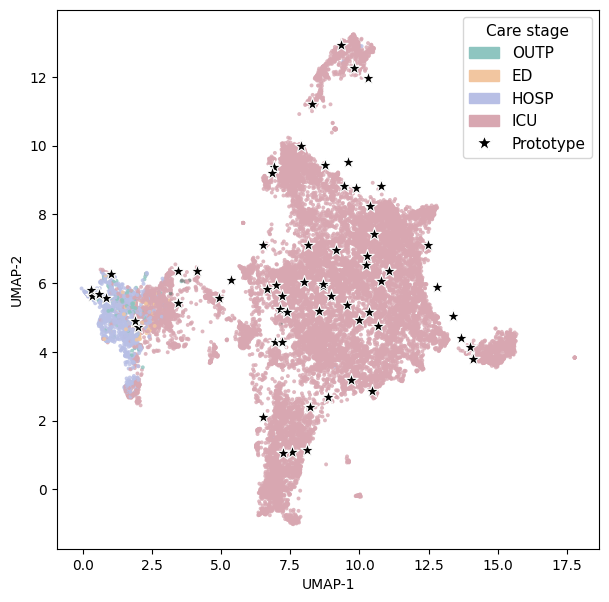

In [44]:
# --- color mapping ---
stage_color_map = {
    "OUTP": "#8EC5C0",   # soft teal
    "ED":   "#F2C6A0",   # muted peach
    "HOSP": "#B8BFE5",   # soft lavender-blue
    "ICU":  "#D8A7B1",   # muted rose
}

colors = [stage_color_map.get(s, "gray") for s in stage_labels]

# --- plot ---
plt.figure(figsize=(7, 7))

# chunks
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=colors,
    s=8,
    alpha=0.8,
    edgecolor="none", rasterized=True
)

# prototypes (overlay)
plt.scatter(
    proto_2d[:, 0],
    proto_2d[:, 1],
    c="black",
    marker="*",
    s=100,
    edgecolor="white",
    linewidth=0.8,
    label="Prototypes"
)

# legend for stages
legend_handles = [
    mpatches.Patch(color=color, label=stage)
    for stage, color in stage_color_map.items()
]

# add prototype legend manually
legend_handles.append(
    plt.Line2D([0], [0], marker='*', color='w',
               markerfacecolor='black', markersize=12,
               label='Prototype')
)

plt.legend(handles=legend_handles, title="Care stage", loc="best",fontsize=11, title_fontsize=11)

# plt.title("UMAP of history chunk embeddings with prototype centers")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.savefig('./figures/umap-mort-yr.pdf', dpi=600, bbox_inches="tight")
plt.show()

In [45]:
# # ICU chunks only

# import torch
# import numpy as np
# import umap
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from tqdm.notebook import tqdm

# ICU_TYPES = {
#     14: "ICU-CHART",
#     15: "ICU-FLUID-OUTPUT",
#     16: "ICU-INFUSION",
#     17: "ICU-PROCEDURE",
# }
# ICU_RATIO_TH = 0.30


# def icu_signal_label(type_ids_chunk, attn_mask_chunk):
#     valid = attn_mask_chunk.bool()
#     types = type_ids_chunk[valid]

#     present = set(int(t.item()) for t in types)

#     signals = []
#     for t, name in ICU_TYPES.items():
#         if t in present:
#             signals.append(name)

#     # prioritize informative signals
#     if "ICU-PROCEDURE" in signals:
#         return "ICU-PROCEDURE"
#     if "ICU-INFUSION" in signals:
#         return "ICU-INFUSION"
#     if "ICU-FLUID-OUTPUT" in signals:
#         return "ICU-FLUID-OUTPUT"
#     if "ICU-CHART" in signals:
#         return "ICU-CHART"

#     return "OTHER"


# def is_icu_chunk(stage_ids_chunk, type_ids_chunk, attn_mask_chunk):
#     valid = attn_mask_chunk.bool()
#     if valid.sum() == 0:
#         return False

#     stages = stage_ids_chunk[valid]
#     types = type_ids_chunk[valid]

#     dom_stage = int(torch.mode(stages).values.item())
#     if dom_stage != 3:
#         return False

#     icu_count = sum(int(t.item()) in ICU_TYPES for t in types)
#     total = int(valid.sum().item())
#     icu_ratio = icu_count / max(total, 1)

#     return icu_ratio >= ICU_RATIO_TH


# def collect_icu_chunks_for_umap(model, dataloader, device="cuda", max_chunks=50000):
#     model = model.to(device)
#     model.eval()

#     all_embs = []
#     all_dom_types = []
#     all_proto_ids = []
#     all_proto_conf = []

#     total = 0

#     with torch.no_grad():
#         for batch in tqdm(dataloader):
#             batch = move_to_device(batch, device)

#             enc_out = model.encoders(batch, query_key="query", history_key="history")
#             proto = model.prototypes(
#                 query_vec=enc_out["query_vec"],
#                 hist_vec=enc_out["hist_vec"],
#                 hist_valid_mask=batch["history_valid_mask"],
#             )

#             hist_vec = enc_out["hist_vec"]                  # [B, K, H]
#             h_probs = proto["hist_probs"]                   # [B, K, P]
#             valid_chunks = batch["history_valid_mask"].bool()

#             stage_ids = batch["history"]["stage_ids"]        # [B, K, C]
#             type_ids = batch["history"]["type_ids"]          # [B, K, C]
#             attn = batch["history"]["attention_mask"].bool() # [B, K, C]

#             B, K, H = hist_vec.shape

#             for b in range(B):
#                 for k in range(K):
#                     if not valid_chunks[b, k]:
#                         continue

#                     if not is_icu_chunk(stage_ids[b, k], type_ids[b, k], attn[b, k]):
#                         continue

#                     dom_type = icu_signal_label(type_ids[b, k], attn[b, k])

#                     probs = h_probs[b, k]
#                     proto_conf, proto_id = probs.max(dim=-1)

#                     all_embs.append(hist_vec[b, k].detach().cpu())
#                     all_dom_types.append(dom_type)
#                     all_proto_ids.append(int(proto_id.detach().cpu().item()))
#                     all_proto_conf.append(float(proto_conf.detach().cpu().item()))

#                     total += 1
#                     if total >= max_chunks:
#                         break

#                 if total >= max_chunks:
#                     break

#             if total >= max_chunks:
#                 break

#     return {
#         "embeddings": torch.stack(all_embs).numpy(),
#         "dominant_icu_type": np.array(all_dom_types),
#         "proto_ids": np.array(all_proto_ids),
#         "proto_conf": np.array(all_proto_conf),
#     }


# icu_data = collect_icu_chunks_for_umap(
#     model=model1,
#     dataloader=test_dataloader,
#     device="cuda",
#     max_chunks=20000,
# )



In [46]:
# X_icu = icu_data["embeddings"]
# icu_type_labels = icu_data["dominant_icu_type"]

# reducer_icu = umap.UMAP(
#     n_neighbors=30,
#     min_dist=0.1,
#     metric="cosine",
#     random_state=42,
# )

# X_icu_2d = reducer_icu.fit_transform(X_icu)

# proto_vecs = model1.prototypes.prototypes.detach().cpu().numpy()
# proto_icu_2d = reducer_icu.transform(proto_vecs)

# type_color_map = {
#     "ICU-CHART": "tab:red",
#     "ICU-FLUID-OUTPUT": "tab:blue",
#     "ICU-INFUSION": "tab:purple",
#     "ICU-PROCEDURE": "tab:orange",
#     "OTHER": "gray",
# }

# colors = [type_color_map.get(t, "gray") for t in icu_type_labels]

# plt.figure(figsize=(9, 7))


# plt.scatter(
#     X_icu_2d[mask, 0],
#     X_icu_2d[mask, 1],
#     c=colors,
#     cmap="tab20",
#     s=18,
#     alpha=0.9,
# )

# plt.scatter(
#     proto_icu_2d[:, 0],
#     proto_icu_2d[:, 1],
#     c="black",
#     marker="*",
#     s=170,
#     edgecolor="white",
#     linewidth=0.8,
#     label="Prototype",
# )

# legend_handles = [
#     mpatches.Patch(color=color, label=label)
#     for label, color in type_color_map.items()
# ]

# legend_handles.append(
#     plt.Line2D(
#         [0], [0],
#         marker="*",
#         color="w",
#         markerfacecolor="black",
#         markeredgecolor="white",
#         markersize=11,
#         label="Prototype",
#     )
# )

# plt.legend(handles=legend_handles, title="Dominant ICU signal", loc="best")
# plt.title("UMAP of ICU history chunks colored by dominant ICU signal")
# plt.xlabel("UMAP-1")
# plt.ylabel("UMAP-2")
# plt.show()

In [47]:
# import numpy as np
# import matplotlib.pyplot as plt

# def collect_sample_h_probs(model, dataloader, device="cuda", max_chunks=20000):
#     model = model.to(device)
#     model.eval()

#     all_probs = []
#     all_stages = []

#     with torch.no_grad():
#         total = 0
#         for batch in tqdm(dataloader):
#             batch = move_to_device(batch, device)

#             enc_out = model.encoders(batch, query_key="query", history_key="history")
#             proto = model.prototypes(
#                 query_vec=enc_out["query_vec"],
#                 hist_vec=enc_out["hist_vec"],
#                 hist_valid_mask=batch["history_valid_mask"],
#             )

#             h_probs = proto["hist_probs"]                  # [B, K, P]
#             valid = batch["history_valid_mask"].bool()     # [B, K]

#             stage_ids = batch["history"]["stage_ids"]
#             type_ids = batch["history"]["type_ids"]
#             attn = batch["history"]["attention_mask"].bool()

#             B, K, P = h_probs.shape

#             for b in range(B):
#                 for k in range(K):
#                     if not valid[b, k]:
#                         continue

#                     stage = infer_chunk_stage(
#                         stage_ids[b, k],
#                         type_ids[b, k],
#                         attn[b, k],
#                     )

#                     all_probs.append(h_probs[b, k].detach().cpu())
#                     all_stages.append(stage)

#                     total += 1
#                     if total >= max_chunks:
#                         break

#                 if total >= max_chunks:
#                     break

#             if total >= max_chunks:
#                 break

#     return {
#         "h_probs": torch.stack(all_probs).numpy(),   # [N, P]
#         "stage_labels": np.array(all_stages),
#     }


# sample_proto = collect_sample_h_probs(
#     model=model1,
#     dataloader=test_dataloader,
#     device="cuda",
#     max_chunks=10000,
# )

# H = sample_proto["h_probs"]          # [N, P]
# stages = sample_proto["stage_labels"]

# stage_order = ["OUTP", "ED", "HOSP", "ICU"]
# P = H.shape[1]

# heat = np.zeros((len(stage_order), P))

# for s_idx, s in enumerate(stage_order):
#     mask = stages == s
#     if mask.sum() > 0:
#         heat[s_idx] = H[mask].mean(axis=0)

# plt.figure(figsize=(14, 4))
# plt.imshow(heat, aspect="auto")
# plt.yticks(range(len(stage_order)), stage_order)
# plt.xlabel("Prototype ID")
# plt.ylabel("Care stage")
# plt.title("Average prototype assignment by care stage")
# plt.colorbar(label="Mean prototype probability")
# plt.show()

In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def move_to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device, non_blocking=True)
    if isinstance(x, dict):
        return {k: move_to_device(v, device) for k, v in x.items()}
    if isinstance(x, list):
        return [move_to_device(v, device) for v in x]
    return x


def collect_rank_weight_stats(
    model,
    dataloader,
    device="cuda",
    max_batches=100,
):
    model = model.to(device)
    model.eval()

    all_weights = []
    all_masks = []
    top_weight_ranks = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader)):
            if batch_idx >= max_batches:
                break

            batch = move_to_device(batch, device)

            enc_out = model.encoders(
                batch,
                query_key="query",
                history_key="history",
            )

            proto = model.prototypes(
                query_vec=enc_out["query_vec"],
                hist_vec=enc_out["hist_vec"],
                hist_valid_mask=batch["history_valid_mask"],
            )

            weights = proto["attn_weights"]                 # [B, K]
            valid = batch["history_valid_mask"].bool()      # [B, K]

            B, K = weights.shape

            for b in range(B):
                w = weights[b].detach().cpu().numpy()       # [K]
                m = valid[b].detach().cpu().numpy().astype(bool)  # [K]

                if m.sum() == 0:
                    continue

                all_weights.append(w)
                all_masks.append(m)

                # top-weight rank among valid chunks only
                valid_idx = np.where(m)[0]
                w_valid = w[valid_idx]
                top_local = np.argmax(w_valid)
                top_original_rank = valid_idx[top_local] + 1  # 1-based C index
                top_weight_ranks.append(top_original_rank)

    all_weights = np.stack(all_weights)  # [N, K]
    all_masks = np.stack(all_masks)      # [N, K]
    top_weight_ranks = np.array(top_weight_ranks)

    # masked mean/std by similarity rank
    masked_weights = np.where(all_masks, all_weights, np.nan)

    mean_weight_by_rank = np.nanmean(masked_weights, axis=0)
    std_weight_by_rank = np.nanstd(masked_weights, axis=0)

    return {
        "all_weights": all_weights,
        "all_masks": all_masks,
        "mean_weight_by_rank": mean_weight_by_rank,
        "std_weight_by_rank": std_weight_by_rank,
        "top_weight_ranks": top_weight_ranks,
    }


rank_stats = collect_rank_weight_stats(
    model=model1,
    dataloader=test_dataloader,
    device="cuda",
    max_batches=13000,
)






  0%|          | 0/12363 [00:00<?, ?it/s]

/tmpdata/ipykernel_474871/1894922215.py:78: RuntimeWarning: Mean of empty slice
  mean_weight_by_rank = np.nanmean(masked_weights, axis=0)


In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rank_transition_heatmap(rank_stats):
    all_weights = rank_stats["all_weights"]   # [N, K]
    all_masks = rank_stats["all_masks"]       # [N, K]

    K = all_weights.shape[1]
    K= K-1
    transition = np.zeros((K, K), dtype=np.float64)

    for w, m in zip(all_weights, all_masks):
        valid_idx = np.where(m)[0]

        if len(valid_idx) == 0:
            continue

        w_valid = w[valid_idx]

        rel_order = np.argsort(-w_valid)
        rel_ranks = np.empty_like(rel_order)
        rel_ranks[rel_order] = np.arange(len(valid_idx))

        for local_i, original_i in enumerate(valid_idx):
            transition[original_i, rel_ranks[local_i]] += 1

    # remove rows with no valid chunks
    row_counts = transition.sum(axis=1)
    valid_rows = row_counts > 0
    transition = transition[valid_rows]

    # normalize each row
    transition = transition / transition.sum(axis=1, keepdims=True).clip(min=1)

    num_rows, num_cols = transition.shape

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(
        transition,
        aspect="auto",
        cmap="Blues_r",
        origin="upper",
    )

    ax.set_yticks(np.arange(num_rows))
    ax.set_yticklabels([f"C{i+1}" for i in np.where(valid_rows)[0]])

    ax.set_xticks(np.arange(num_cols))
    ax.set_xticklabels([f"R{i+1}" for i in range(num_cols)], rotation=45, ha="right")

    ax.set_xlabel("Relevance rank")
    ax.set_ylabel("Original similarity rank")
#     ax.set_title("Transition from similarity rank to EHR-RAG relevance rank")

    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
#     cbar.set_label("Probability")

    plt.tight_layout()
    plt.savefig('./figures/sim-vs-rel-yr-mort.pdf',dpi=600, bbox_inches="tight")
    plt.show()

    return transition

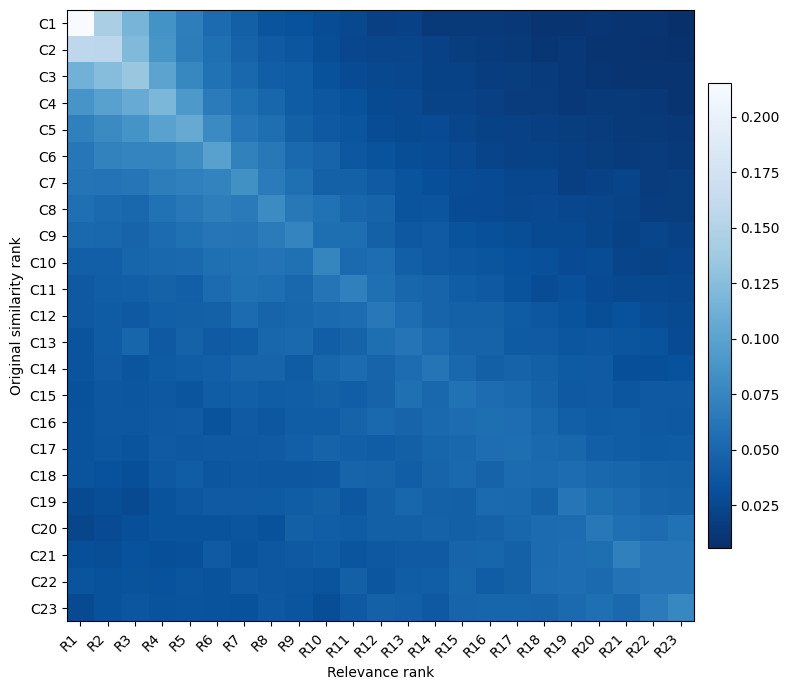

In [77]:
transition = plot_rank_transition_heatmap(
    rank_stats)

In [ ]:
# While similarity ranking induces a coarse alignment with relevance (diagonal trend), each similarity level maps to a range of relevance ranks, particularly in the mid-ranked region. This indicates that similarity alone does not uniquely determine relevance, and the model assigns importance in a context-dependent manner.